In [106]:
import sys, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
os.chdir("/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/")
sys.path.insert(0, "scripts/analysis")


from helpers import (
    FEATURE_NAMES, RENAME, RENAME_INV, ZHOU_SCORES,
    NEW_FEATURES, CANCER_RENAME, CANCER_RENAME_INV,
    load_roc_data, bootstrap_auc_ci, sens_at_spec,
    build_auc_table, build_sensitivity_table,
)
print(NEW_FEATURES)
old_palette = sns.color_palette('deep')

palette = sns.color_palette("tab20", len(FEATURE_NAMES))
sns.set_theme(style='whitegrid', palette=palette)
DIFF_COLORS = {f: palette[i] for i, f in enumerate(FEATURE_NAMES)}
for i in FEATURE_NAMES:
    DIFF_COLORS[RENAME.get(i, i)] = DIFF_COLORS[i]

def feat_color(name):
    return DIFF_COLORS.get(name, DIFF_COLORS.get(RENAME_INV.get(name, name), '#888888'))

def is_new_color(name):
    return old_palette[1] if name in NEW_FEATURES else old_palette[0]



{'ocEDM', 'eoEDM', 'eEDM', 'iEDM'}


## Hyperparameter Tuning

In [107]:
ht_dir = "data/model_results/hyperparam_tuning/"

rbf_mapq0 = pd.read_csv(ht_dir + "rbf_mapq0_1x10.csv")
rbf_mapq15 = pd.read_csv(ht_dir + "rbf_mapq15_1x10.csv")
rbf_mapq30 = pd.read_csv(ht_dir + "rbf_mapq30_1x10.csv")
rbf_mapq45 = pd.read_csv(ht_dir + "rbf_mapq45_1x10.csv")
linear_nopca = pd.read_csv(ht_dir + "linear_nopca_mapq30_1x10.csv")
linear_pca50 = pd.read_csv(ht_dir + "linear_pca50_mapq30_1x10.csv")
linear_pca100 = pd.read_csv(ht_dir + "linear_pca100_mapq30_1x10.csv")
linear_pca150 = pd.read_csv(ht_dir + "linear_pca150_mapq30_1x10.csv")
linear_pca200 = pd.read_csv(ht_dir + "linear_pca200_mapq30_1x10.csv")
linear_pca150_gc_1x10 = pd.read_csv(ht_dir + "linear_pca150_gc_mapq30_1x10.csv")
linear_pca150_10x10 = pd.read_csv(ht_dir + "linear_pca150_mapq30_10x10.csv")
linear_pca150_gc_10x10 = pd.read_csv(ht_dir + "linear_pca150_gc_mapq30_10x10.csv")

zhou_ref = pd.DataFrame(list(ZHOU_SCORES.items()), columns=['feature', 'zhou'])

def merge_configs(configs):
    df = pd.DataFrame(FEATURE_NAMES, columns=['feature'])
    for col, dfm in configs.items():
        df = df.merge(dfm[['feature', 'auc']].rename(columns={'auc': col}), on='feature', how='left')
    return df.merge(zhou_ref, on='feature', how='left')

mapq_auc = merge_configs({'MAPQ0': rbf_mapq0, 'MAPQ15': rbf_mapq15, 'MAPQ30': rbf_mapq30, 'MAPQ45': rbf_mapq45})
kernel_auc = merge_configs({'RBF': rbf_mapq30, 'Linear': linear_nopca})
pca_auc = merge_configs({'pca50': linear_pca50, 'pca100': linear_pca100, 'pca150': linear_pca150, 'pca200': linear_pca200, 'no_pca': linear_nopca})
gc_1x10_auc = merge_configs({'gc_false': linear_pca150, 'gc_true': linear_pca150_gc_1x10})
gc_10x10_auc = merge_configs({'gc_false': linear_pca150_10x10, 'gc_true': linear_pca150_gc_10x10})


### MAPQ Filtering Threshold

/tmp/ipykernel_2616392/4157767663.py:8: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='MAPQ', ax=ax, palette=old_palette)
/tmp/ipykernel_2616392/4157767663.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


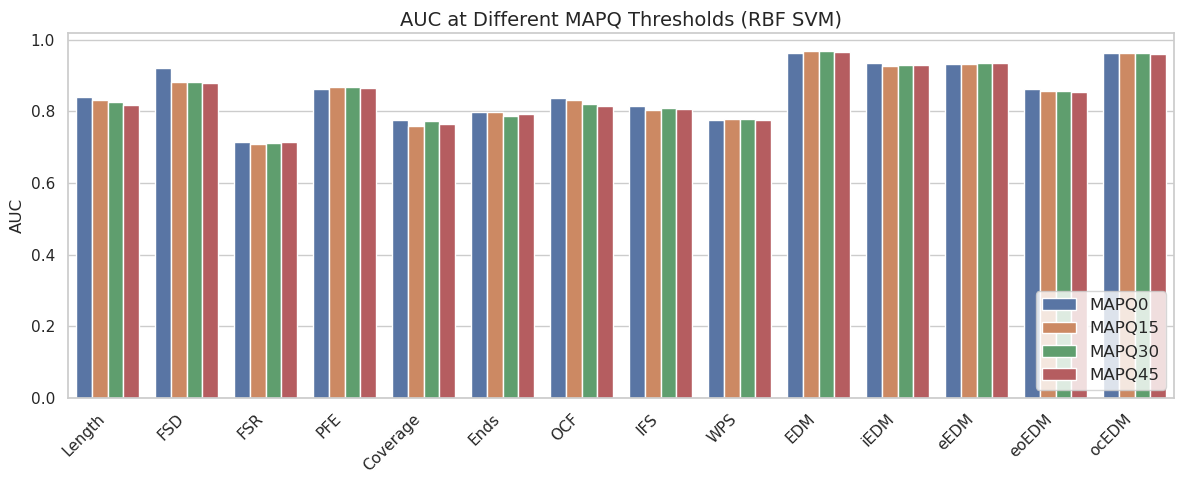

/tmp/ipykernel_2616392/4157767663.py:20: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(data=auc_df_est, x='feature', y='AUC', hue='MAPQ', ax=ax, palette=old_palette)
/tmp/ipykernel_2616392/4157767663.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


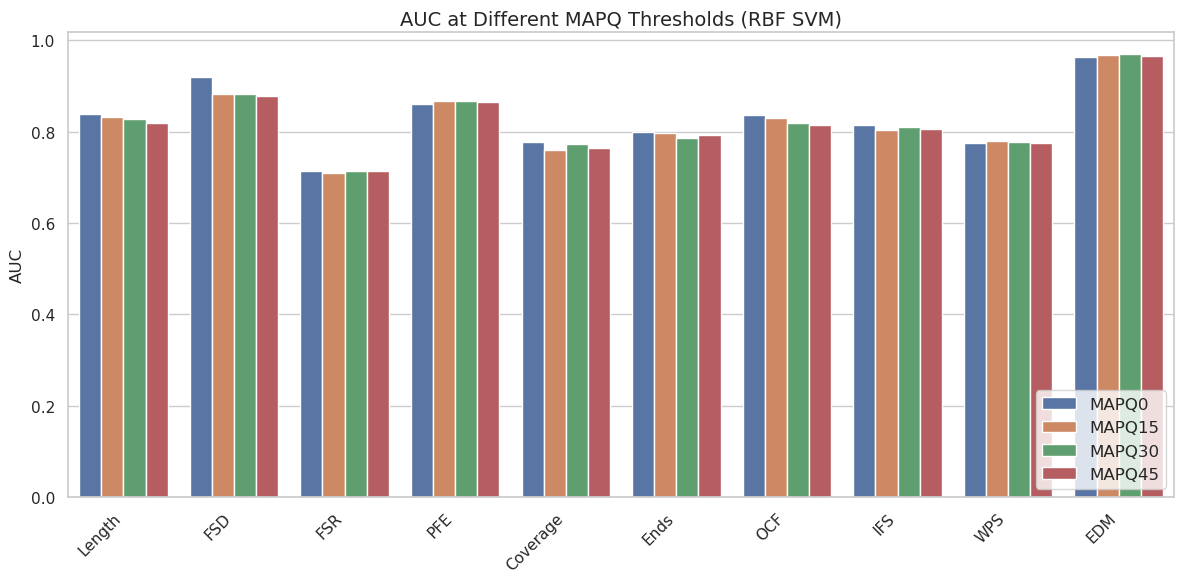

/tmp/ipykernel_2616392/4157767663.py:32: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(data=auc_df_est, x='feature', y='AUC', hue='MAPQ', ax=ax, palette=old_palette)
/tmp/ipykernel_2616392/4157767663.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


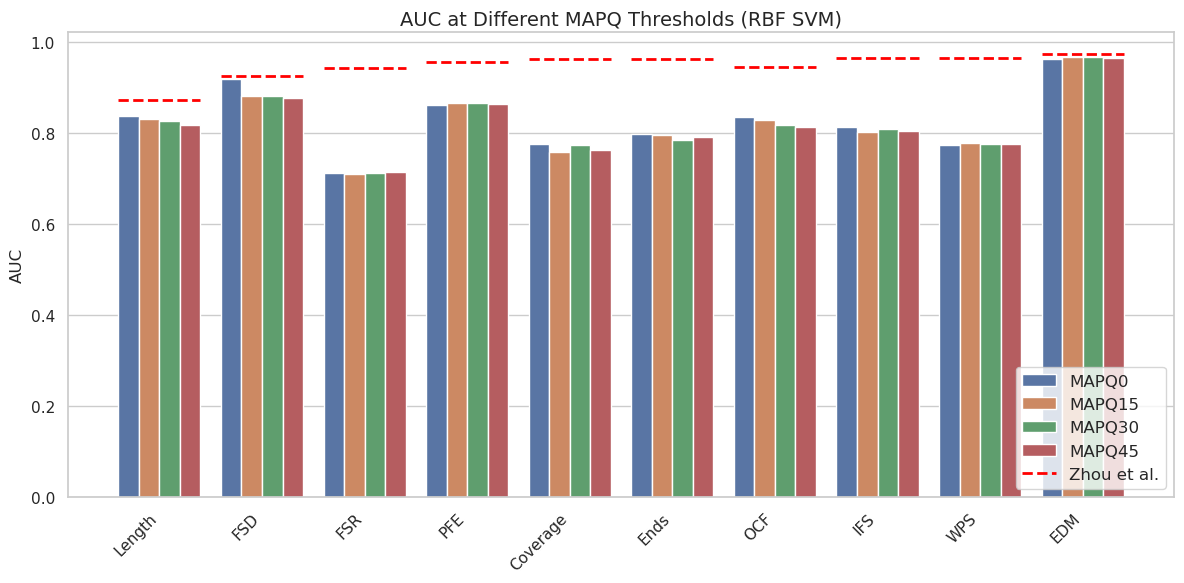

In [108]:
auc_df_melted = mapq_auc.melt(id_vars='feature', value_vars=['MAPQ0', 'MAPQ15', 'MAPQ30', 'MAPQ45'], var_name='MAPQ', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)
auc_df_est = auc_df_melted[~auc_df_melted['feature'].isin(NEW_FEATURES)]
mapq_auc_est = mapq_auc[mapq_auc['feature'].apply(lambda f: RENAME.get(f, f) not in NEW_FEATURES)]

# 1 — all features, no Zhou
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='MAPQ', ax=ax, palette=old_palette)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC at Different MAPQ Thresholds (RBF SVM)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('scripts/analysis/figures/01_mapq_all.png')
plt.show()

# 2 — established features only, no Zhou
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=auc_df_est, x='feature', y='AUC', hue='MAPQ', ax=ax, palette=old_palette)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC at Different MAPQ Thresholds (RBF SVM)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('scripts/analysis/figures/01_mapq_established.png')
plt.show()

# 3 — established features, with Zhou
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=auc_df_est, x='feature', y='AUC', hue='MAPQ', ax=ax, palette=old_palette)
for i, (_, row) in enumerate(mapq_auc_est.iterrows()):
    ax.hlines(row['zhou'], i - 0.4, i + 0.4, colors='red', linewidth=2, linestyles='--',
              label='Zhou et al.' if i == 0 else '')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC at Different MAPQ Thresholds (RBF SVM)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('scripts/analysis/figures/01_mapq_established_zhou.png')
plt.show()


/tmp/ipykernel_2616392/702631365.py:8: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
/tmp/ipykernel_2616392/702631365.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


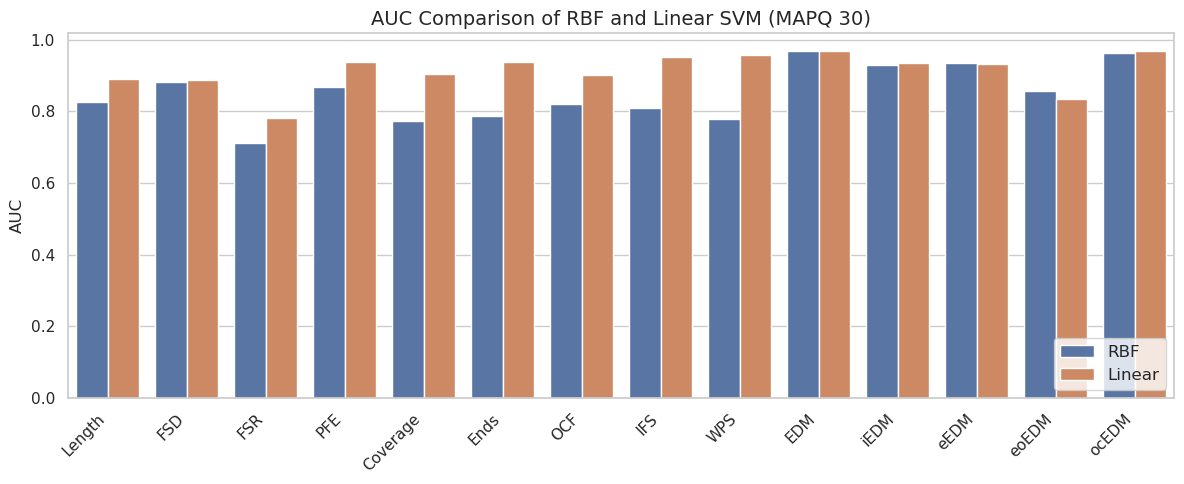

/tmp/ipykernel_2616392/702631365.py:20: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(data=auc_df_est, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
/tmp/ipykernel_2616392/702631365.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


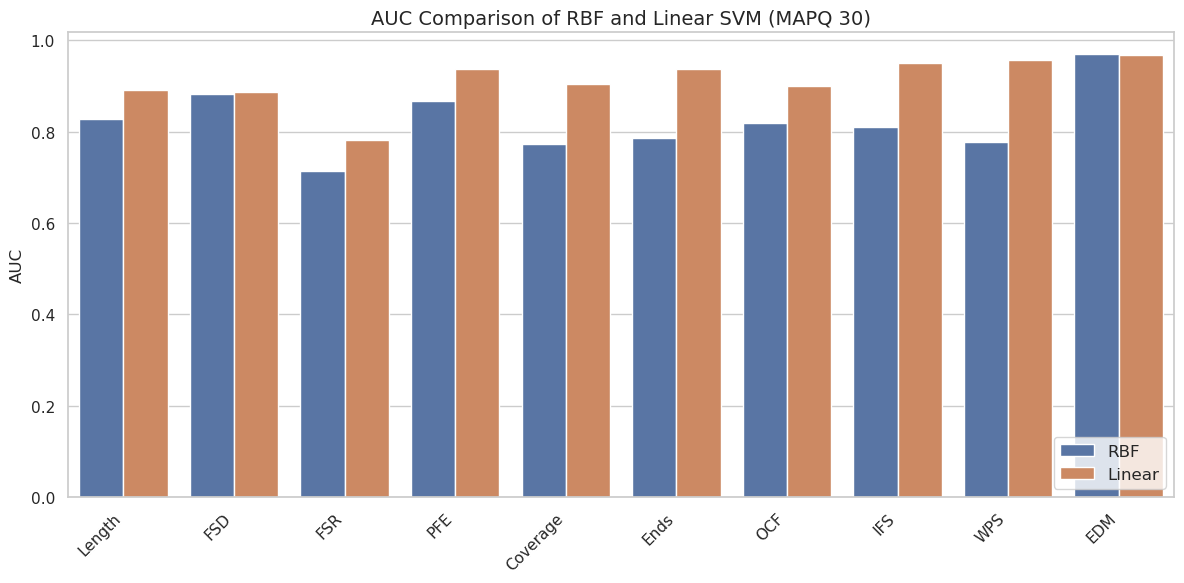

/tmp/ipykernel_2616392/702631365.py:32: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(data=auc_df_est, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
/tmp/ipykernel_2616392/702631365.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


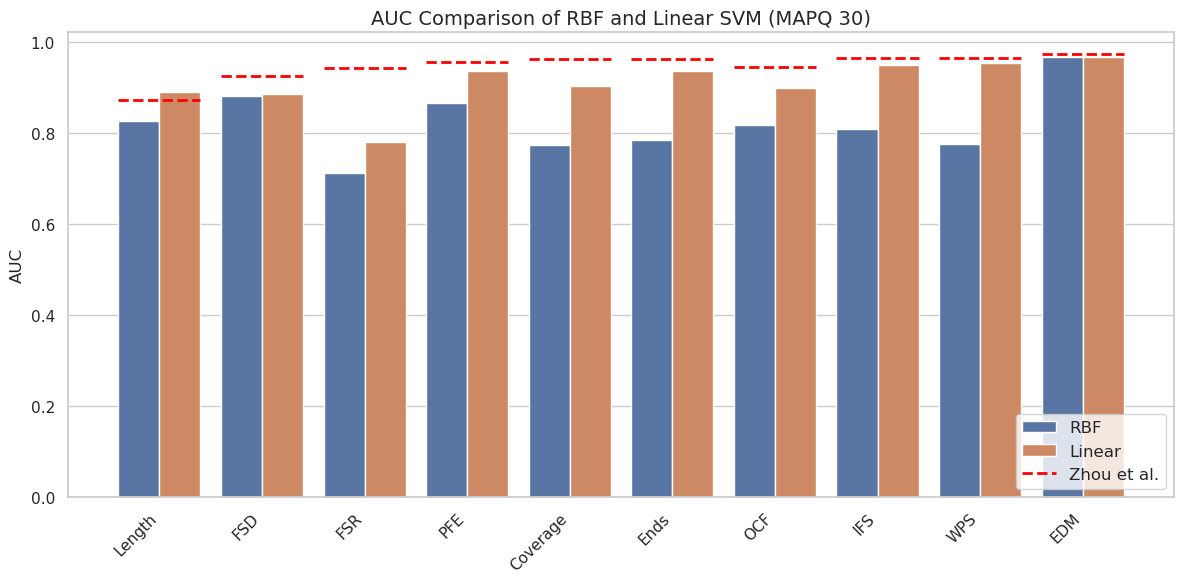

In [109]:
auc_df_melted = kernel_auc.melt(id_vars='feature', value_vars=['RBF', 'Linear'], var_name='Model', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)
auc_df_est = auc_df_melted[~auc_df_melted['feature'].isin(NEW_FEATURES)]
kernel_auc_est = kernel_auc[kernel_auc['feature'].apply(lambda f: RENAME.get(f, f) not in NEW_FEATURES)]

# 1 — all features, no Zhou
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC Comparison of RBF and Linear SVM (MAPQ 30)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('scripts/analysis/figures/02_kernel_all.png')
plt.show()

# 2 — established features only, no Zhou
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=auc_df_est, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC Comparison of RBF and Linear SVM (MAPQ 30)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('scripts/analysis/figures/02_kernel_established.png')
plt.show()

# 3 — established features, with Zhou
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=auc_df_est, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
for i, (_, row) in enumerate(kernel_auc_est.iterrows()):
    ax.hlines(row['zhou'], i - 0.4, i + 0.4, colors='red', linewidth=2, linestyles='--',
              label='Zhou et al.' if i == 0 else '')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC Comparison of RBF and Linear SVM (MAPQ 30)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('scripts/analysis/figures/02_kernel_established_zhou.png')
plt.show()


## PCA

/tmp/ipykernel_2616392/195299831.py:8: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
/tmp/ipykernel_2616392/195299831.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


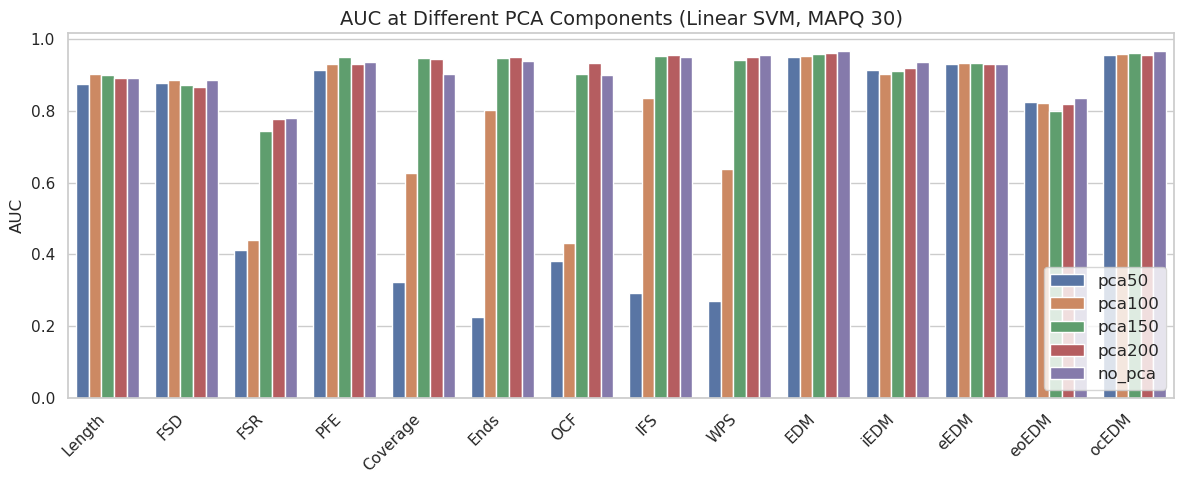

/tmp/ipykernel_2616392/195299831.py:20: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.barplot(data=auc_df_est, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
/tmp/ipykernel_2616392/195299831.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


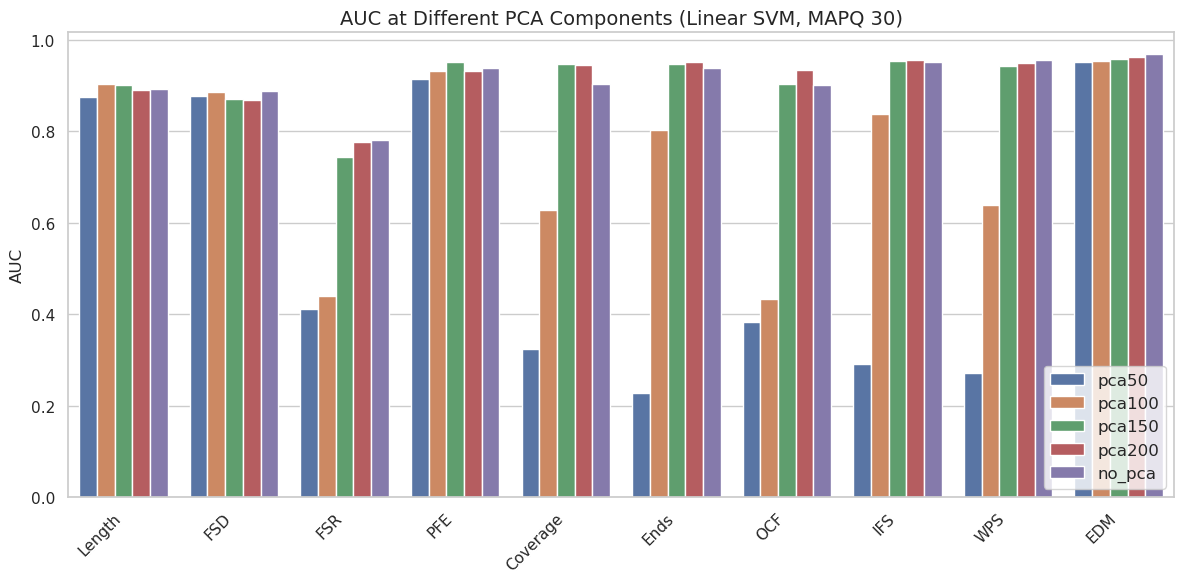

/tmp/ipykernel_2616392/195299831.py:32: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.barplot(data=auc_df_est, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
/tmp/ipykernel_2616392/195299831.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


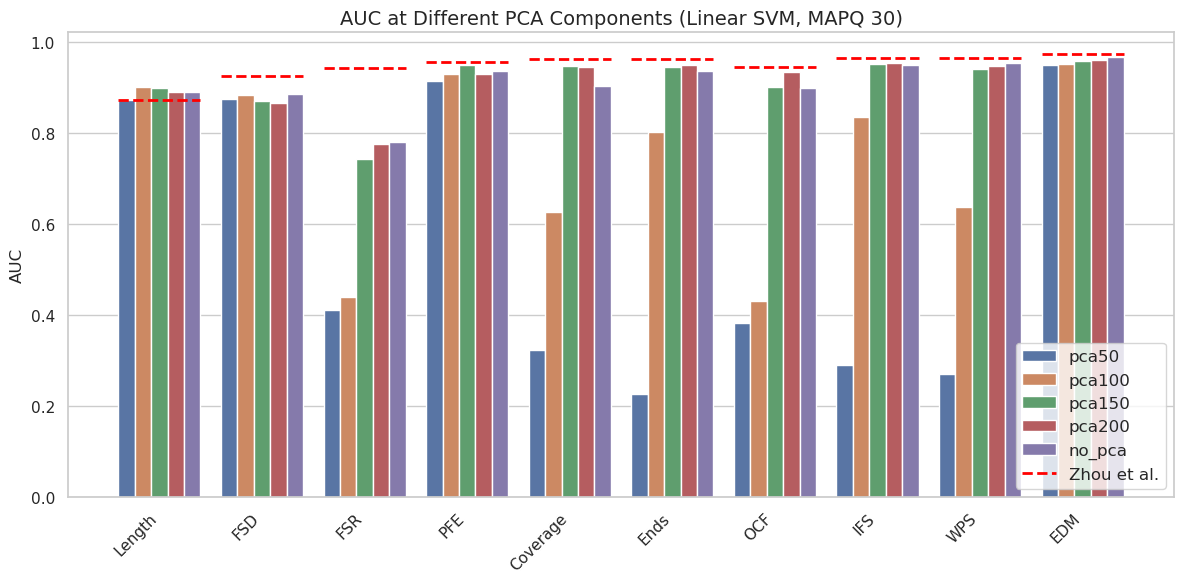

In [110]:
auc_df_melted = pca_auc.melt(id_vars='feature', value_vars=['pca50', 'pca100', 'pca150', 'pca200', 'no_pca'], var_name='Model', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)
auc_df_est = auc_df_melted[~auc_df_melted['feature'].isin(NEW_FEATURES)]
pca_auc_est = pca_auc[pca_auc['feature'].apply(lambda f: RENAME.get(f, f) not in NEW_FEATURES)]

# 1 — all features, no Zhou
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC at Different PCA Components (Linear SVM, MAPQ 30)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('scripts/analysis/figures/03_pca_all.png')
plt.show()

# 2 — established features only, no Zhou
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=auc_df_est, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC at Different PCA Components (Linear SVM, MAPQ 30)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('scripts/analysis/figures/03_pca_established.png')
plt.show()

# 3 — established features, with Zhou
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=auc_df_est, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
for i, (_, row) in enumerate(pca_auc_est.iterrows()):
    ax.hlines(row['zhou'], i - 0.4, i + 0.4, colors='red', linewidth=2, linestyles='--',
              label='Zhou et al.' if i == 0 else '')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC at Different PCA Components (Linear SVM, MAPQ 30)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('scripts/analysis/figures/03_pca_established_zhou.png')
plt.show()


## GC Correction

In [111]:
os.makedirs("scripts/analysis/tables", exist_ok=True)
gc_features = ['pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']

table_zhou = gc_1x10_auc[gc_1x10_auc['feature'].isin(gc_features)][['feature', 'gc_false', 'gc_true', 'zhou']].round(4).set_index('feature')
table_zhou.to_csv("scripts/analysis/tables/04_gc_1x10_zhou.csv")
display(table_zhou)

table = gc_1x10_auc[gc_1x10_auc['feature'].isin(gc_features)][['feature', 'gc_false', 'gc_true']].round(4).set_index('feature')
table.to_csv("scripts/analysis/tables/04_gc_1x10.csv")
display(table)


,gc_false,gc_true,zhou
feature,,,
pfe,0.9507,0.9502,0.9579
coverage,0.9476,0.9160,0.9638
ends,0.9465,0.9390,0.9639
ocf,0.9028,0.9143,0.9467
ifs,0.9526,0.9404,0.9653
wps,0.9423,0.9555,0.9658


,gc_false,gc_true
feature,,
pfe,0.9507,0.9502
coverage,0.9476,0.9160
ends,0.9465,0.9390
ocf,0.9028,0.9143
ifs,0.9526,0.9404
wps,0.9423,0.9555


/tmp/ipykernel_2616392/1436102914.py:11: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
/tmp/ipykernel_2616392/1436102914.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


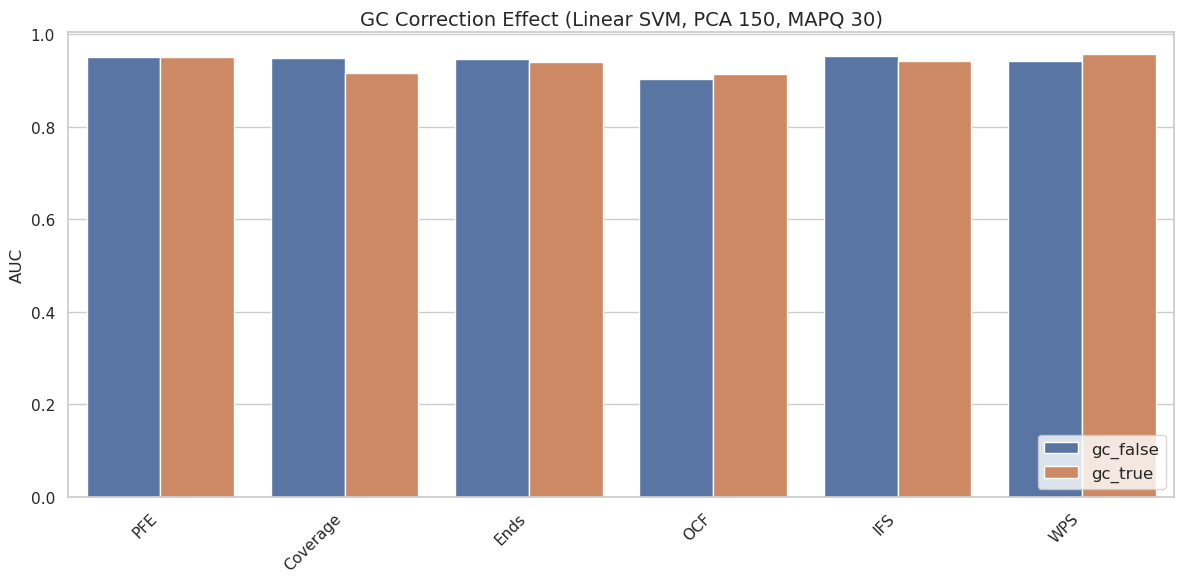

/tmp/ipykernel_2616392/1436102914.py:24: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(data=auc_df_est, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
/tmp/ipykernel_2616392/1436102914.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


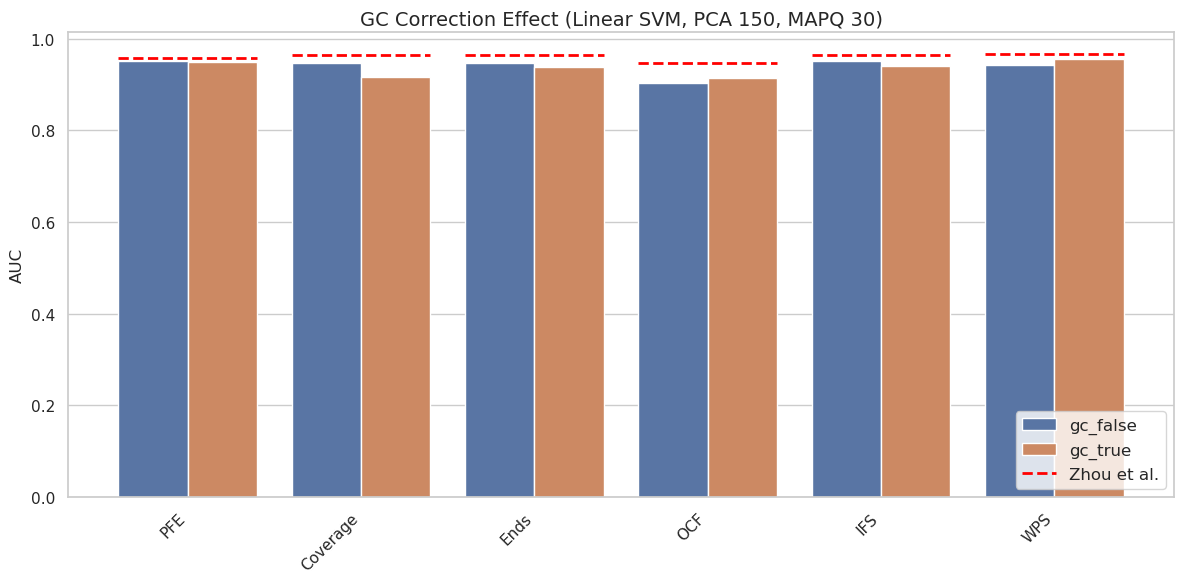

In [112]:
gc_features = ['pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']
auc_df_melted = gc_1x10_auc[gc_1x10_auc['feature'].isin(gc_features)].melt(
    id_vars='feature', value_vars=['gc_false', 'gc_true'], var_name='Model', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)
auc_df_est = auc_df_melted[~auc_df_melted['feature'].isin(NEW_FEATURES)]
gc_1x10_auc_est = gc_1x10_auc[gc_1x10_auc['feature'].isin(gc_features) &
                               gc_1x10_auc['feature'].apply(lambda f: RENAME.get(f, f) not in NEW_FEATURES)]

# 1 — all (gc_features), no Zhou
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('GC Correction Effect (Linear SVM, PCA 150, MAPQ 30)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('scripts/analysis/figures/04_gc_correction.png')
plt.show()


# 2 — established features, with Zhou
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=auc_df_est, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
for i, (_, row) in enumerate(gc_1x10_auc_est.iterrows()):
    ax.hlines(row['zhou'], i - 0.4, i + 0.4, colors='red', linewidth=2, linestyles='--',
              label='Zhou et al.' if i == 0 else '')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('GC Correction Effect (Linear SVM, PCA 150, MAPQ 30)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('scripts/analysis/figures/04_gc_correction_zhou.png')
plt.show()


In [113]:
gc_features = ['pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']

table_zhou = gc_1x10_auc[gc_1x10_auc['feature'].isin(gc_features)].set_index('feature')[['gc_true', 'zhou']].round(4).rename(
    columns={'gc_true': 'linear_pca150_gc_1x10', 'zhou': 'zhou_et_al'})
table_zhou.to_csv("scripts/analysis/tables/04_gc_1x10_summary_zhou.csv")
display(table_zhou)

table = gc_1x10_auc[gc_1x10_auc['feature'].isin(gc_features)].set_index('feature')[['gc_true']].round(4).rename(
    columns={'gc_true': 'linear_pca150_gc_1x10'})
table.to_csv("scripts/analysis/tables/04_gc_1x10_summary.csv")
display(table)


,linear_pca150_gc_1x10,zhou_et_al
feature,,
pfe,0.9502,0.9579
coverage,0.9160,0.9638
ends,0.9390,0.9639
ocf,0.9143,0.9467
ifs,0.9404,0.9653
wps,0.9555,0.9658


,linear_pca150_gc_1x10
feature,
pfe,0.9502
coverage,0.9160
ends,0.9390
ocf,0.9143
ifs,0.9404
wps,0.9555


In [114]:
gc_features = ['pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']

table_zhou = gc_10x10_auc[gc_10x10_auc['feature'].isin(gc_features)][['feature', 'gc_false', 'gc_true', 'zhou']].round(4).set_index('feature')
table_zhou.to_csv("scripts/analysis/tables/05_gc_10x10_zhou.csv")
display(table_zhou)

table = gc_10x10_auc[gc_10x10_auc['feature'].isin(gc_features)][['feature', 'gc_false', 'gc_true']].round(4).set_index('feature')
table.to_csv("scripts/analysis/tables/05_gc_10x10.csv")
display(table)


,gc_false,gc_true,zhou
feature,,,
pfe,0.9427,0.9540,0.9579
coverage,0.9566,0.9506,0.9638
ends,0.9606,0.9577,0.9639
ocf,0.9345,0.9156,0.9467
ifs,0.9610,0.9604,0.9653
wps,0.9517,0.9576,0.9658


,gc_false,gc_true
feature,,
pfe,0.9427,0.9540
coverage,0.9566,0.9506
ends,0.9606,0.9577
ocf,0.9345,0.9156
ifs,0.9610,0.9604
wps,0.9517,0.9576


/tmp/ipykernel_2616392/1697832549.py:11: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
/tmp/ipykernel_2616392/1697832549.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


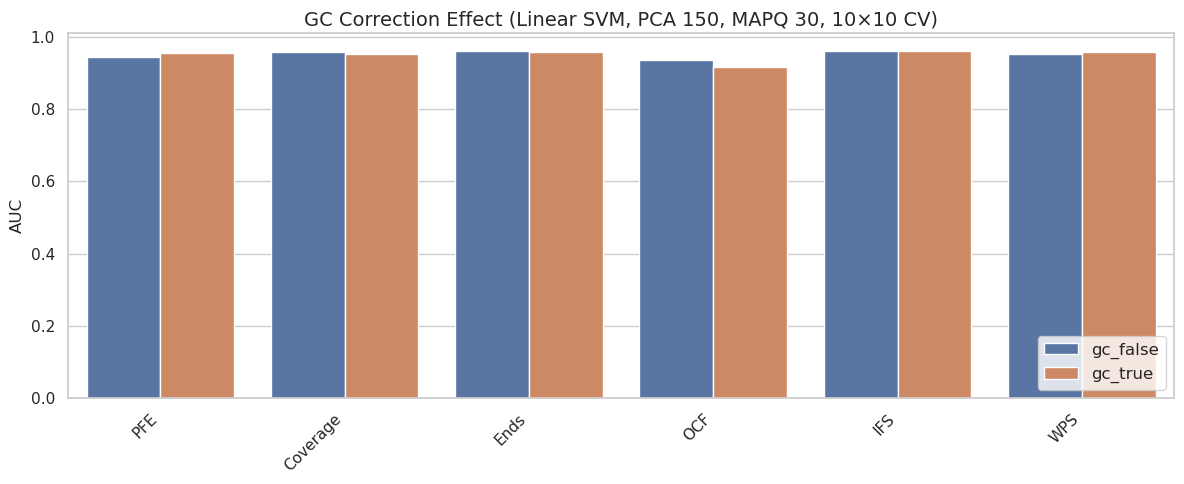

/tmp/ipykernel_2616392/1697832549.py:24: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(data=auc_df_est, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
/tmp/ipykernel_2616392/1697832549.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


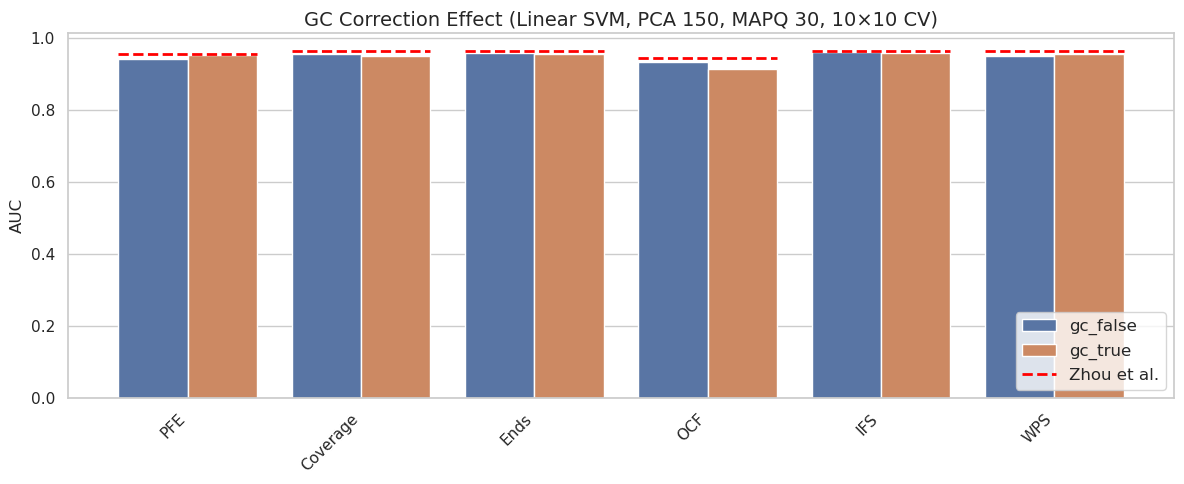

In [115]:
gc_features = ['pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']
auc_df_melted = gc_10x10_auc[gc_10x10_auc['feature'].isin(gc_features)].melt(
    id_vars='feature', value_vars=['gc_false', 'gc_true'], var_name='Model', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)
auc_df_est = auc_df_melted[~auc_df_melted['feature'].isin(NEW_FEATURES)]
gc_10x10_auc_est = gc_10x10_auc[gc_10x10_auc['feature'].isin(gc_features) &
                                 gc_10x10_auc['feature'].apply(lambda f: RENAME.get(f, f) not in NEW_FEATURES)]

# 1 — all (gc_features), no Zhou
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('GC Correction Effect (Linear SVM, PCA 150, MAPQ 30, 10×10 CV)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('scripts/analysis/figures/05_gc_cv10.png')
plt.show()


# 2 — established features, with Zhou
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=auc_df_est, x='feature', y='AUC', hue='Model', ax=ax, palette=old_palette)
for i, (_, row) in enumerate(gc_10x10_auc_est.iterrows()):
    ax.hlines(row['zhou'], i - 0.4, i + 0.4, colors='red', linewidth=2, linestyles='--',
              label='Zhou et al.' if i == 0 else '')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('GC Correction Effect (Linear SVM, PCA 150, MAPQ 30, 10×10 CV)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('scripts/analysis/figures/05_gc_cv10_zhou.png')
plt.show()


## B — Cristiano 10×10 CV (per-feature)

In [116]:
cv_dir   = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/cv/"
manifest = pd.read_csv("data/manifest/Cristiano_metadata.csv")[['sample_id', 'disease', 'stage']]

cv_roc = load_roc_data(cv_dir, suffix='_cv_probs.csv')
names  = [d['name'] for d in cv_roc]
aucs   = [d['auc']  for d in cv_roc]

probs_wide = None
for feat in FEATURE_NAMES:
    path = cv_dir + f"{feat}_cv_probs.csv"
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path)[['sample_id', 'probability']].rename(columns={'probability': feat})
    probs_wide = df if probs_wide is None else probs_wide.merge(df, on='sample_id')

stage_probs = []
for feat in FEATURE_NAMES:
    path = cv_dir + f"{feat}_cv_probs.csv"
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path)[['sample_id', 'probability', 'label']].merge(manifest, on='sample_id', how='left')
    healthy = df[df['disease'] == 'Healthy']
    for stage in ['I', 'II', 'III', 'IV']:
        cancer = df[(df['label'] == 1) & (df['stage'] == stage)]
        if len(cancer) == 0:
            continue
        subset = pd.concat([cancer, healthy])
        auc_val = roc_auc_score(subset['label'], subset['probability'])
        stage_probs.append({'feature': RENAME.get(feat, feat), 'stage': stage, 'auc': auc_val, 'n': len(cancer)})
stage_auc = pd.DataFrame(stage_probs)

cancer_type_records = []
for feat in FEATURE_NAMES:
    path = cv_dir + f"{feat}_cv_probs.csv"
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path)[['sample_id', 'probability', 'label']].merge(manifest, on='sample_id', how='left')
    healthy_df = df[df['disease'] == 'Healthy']
    for ct in df[df['label'] == 1]['disease'].unique():
        cancer_df = df[df['disease'] == ct]
        if len(cancer_df) < 5:
            continue
        subset = pd.concat([cancer_df, healthy_df])
        cancer_type_records.append({
            'feature': RENAME.get(feat, feat), 'cancer_type': ct,
            'auc': roc_auc_score(subset['label'], subset['probability']),
            'n': len(cancer_df)
        })
cancer_type_auc_df = pd.DataFrame(cancer_type_records)


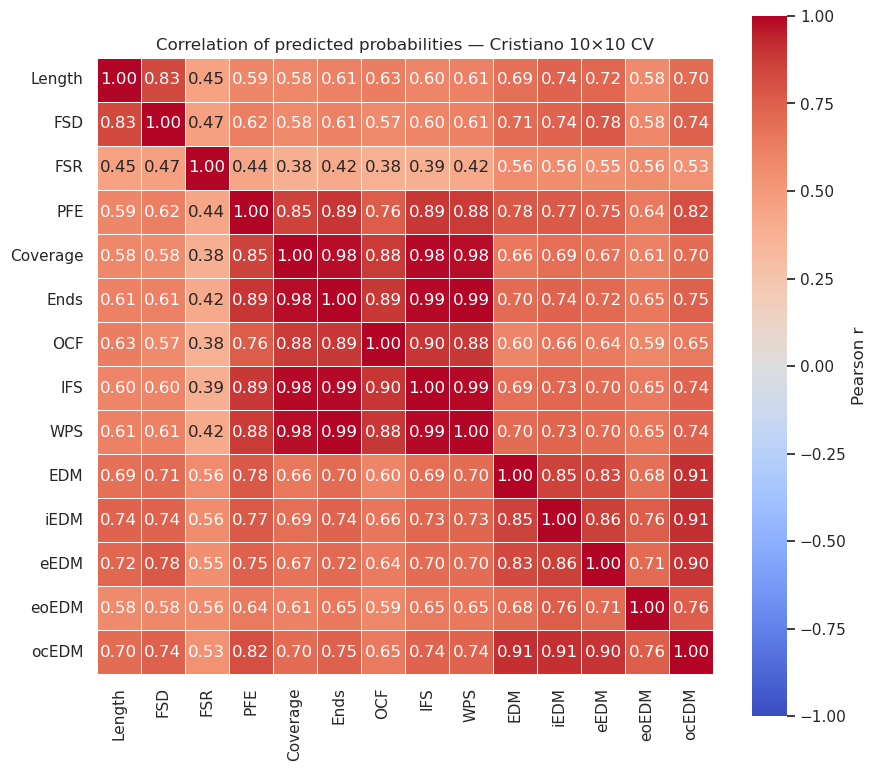

In [117]:
# B5 — Feature correlation heatmap
corr = probs_wide.drop(columns='sample_id').rename(columns=RENAME).corr()
plt.figure(figsize=(9, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, square=True, cbar_kws={'label': 'Pearson r'})
plt.title('Correlation of predicted probabilities — Cristiano 10×10 CV')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/B5_feature_corr.png")
plt.show()


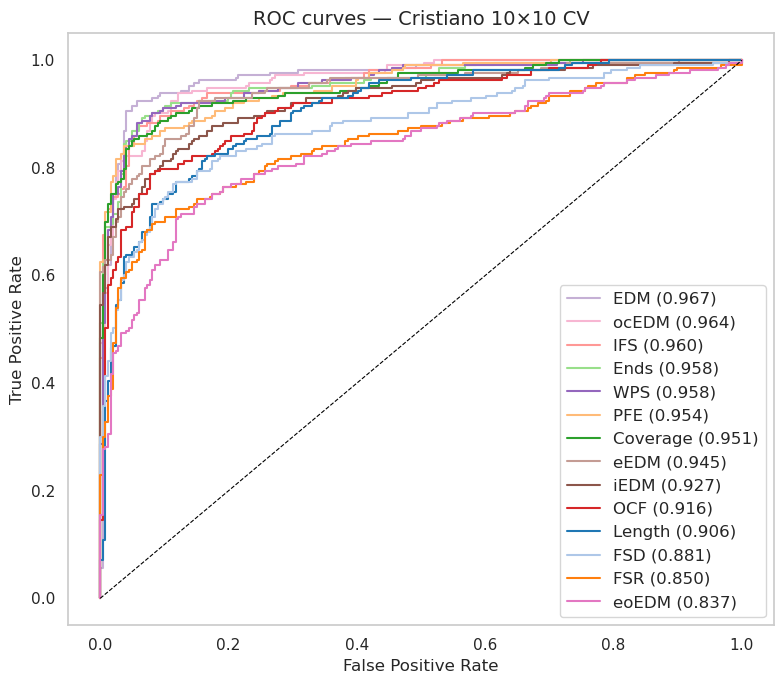

In [118]:
# B6 — ROC curves all features
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_palette(palette)
for d in cv_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves — Cristiano 10×10 CV', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/B6_roc_cv.png", bbox_inches='tight')
plt.show()


In [119]:
# barplot of per-feature ROC

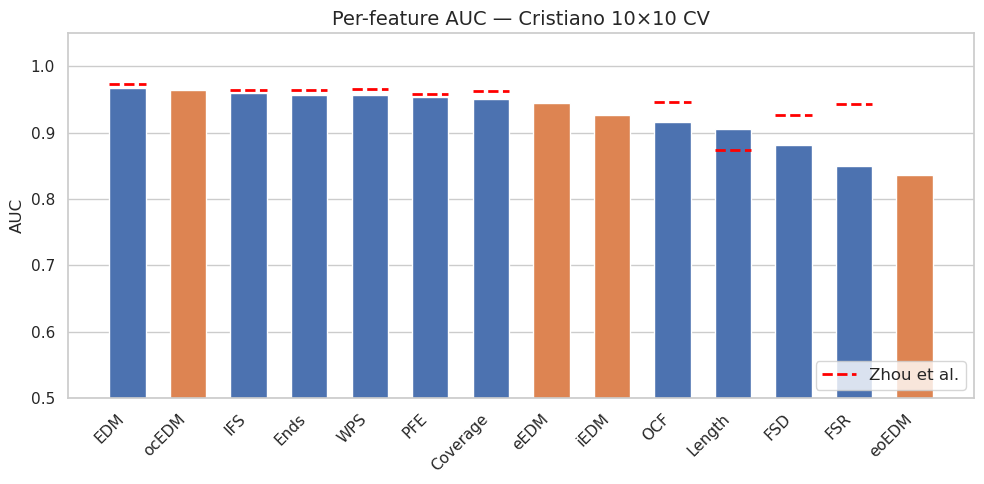

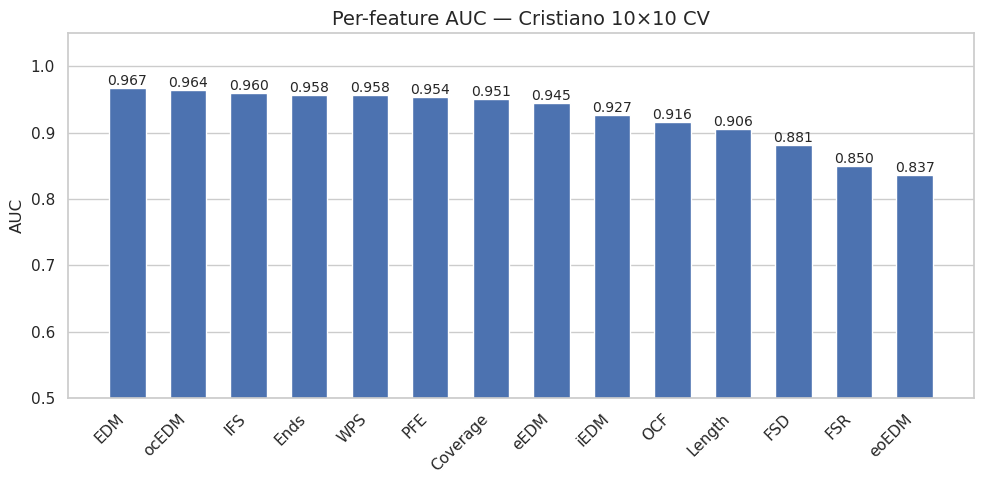

In [120]:
# B7 — AUC bars vs Zhou
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(names)), aucs, color=[is_new_color(n) for n in names], width=0.6)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_ylim(0.5, 1.05); ax.set_ylabel('AUC')
# times symbol
ax.set_title('Per-feature AUC — Cristiano 10×10 CV', fontsize=14)
for i, n in enumerate(names):
    z = ZHOU_SCORES.get(RENAME_INV.get(n, n))
    if z is not None:
        ax.hlines(z, i-0.3, i+0.3, colors='red', linewidth=2, linestyles='--',
                label='Zhou et al.' if i == 0 else '')
plt.grid(False, axis='x')
ax.legend(loc='lower right', fontsize=12)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/B7_auc_cv_zhou.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(names)), aucs, color=old_palette[0], width=0.6)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_ylim(0.5, 1.05); ax.set_ylabel('AUC')
ax.set_title('Per-feature AUC — Cristiano 10×10 CV', fontsize=14)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.grid(False, axis='x')
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/B7_auc_cv.png", bbox_inches='tight')
plt.show()


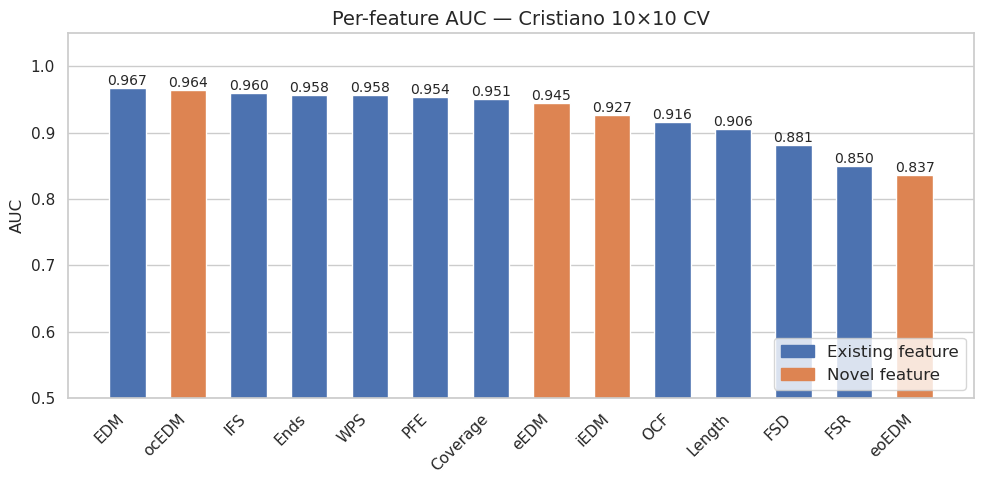

In [121]:
# B7b — AUC bars existing vs novel
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(names)), aucs, color=[is_new_color(n) for n in names], width=0.6)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_ylim(0.5, 1.05); ax.set_ylabel('AUC')
ax.set_title('Per-feature AUC — Cristiano 10×10 CV', fontsize=14)
ax.legend(handles=[Patch(color=old_palette[0], label='Existing feature'),
                   Patch(color=old_palette[1], label='Novel feature')],
          loc='lower right', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.grid(False, axis='x')
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/B7b_auc_oldnew_cv.png", bbox_inches='tight')
plt.show()


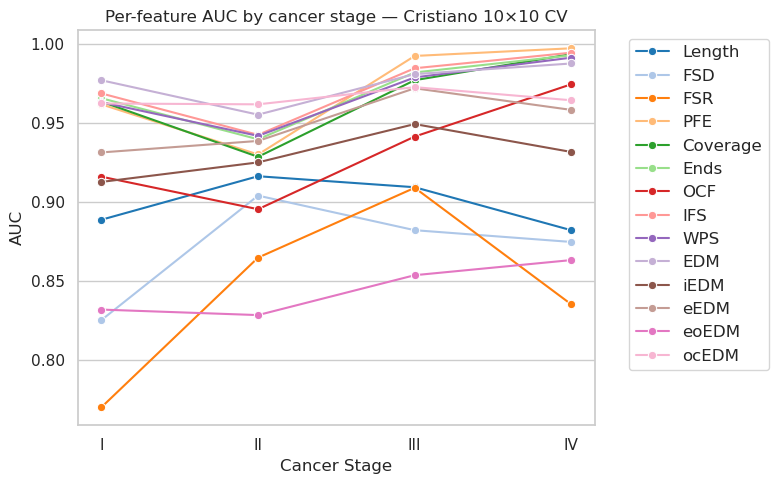

In [122]:
# B9 — Stage-stratified AUC
palette = {RENAME.get(f, f): feat_color(RENAME.get(f, f)) for f in FEATURE_NAMES}
plt.figure(figsize=(8, 5))
sns.lineplot(data=stage_auc, x='stage', y='auc', hue='feature', marker='o', palette=palette)
plt.xlabel('Cancer Stage'); plt.ylabel('AUC')
plt.title('Per-feature AUC by cancer stage — Cristiano 10×10 CV')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.grid(False, axis='x')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/B9_stage_auc_cv.png", bbox_inches='tight')
plt.show()


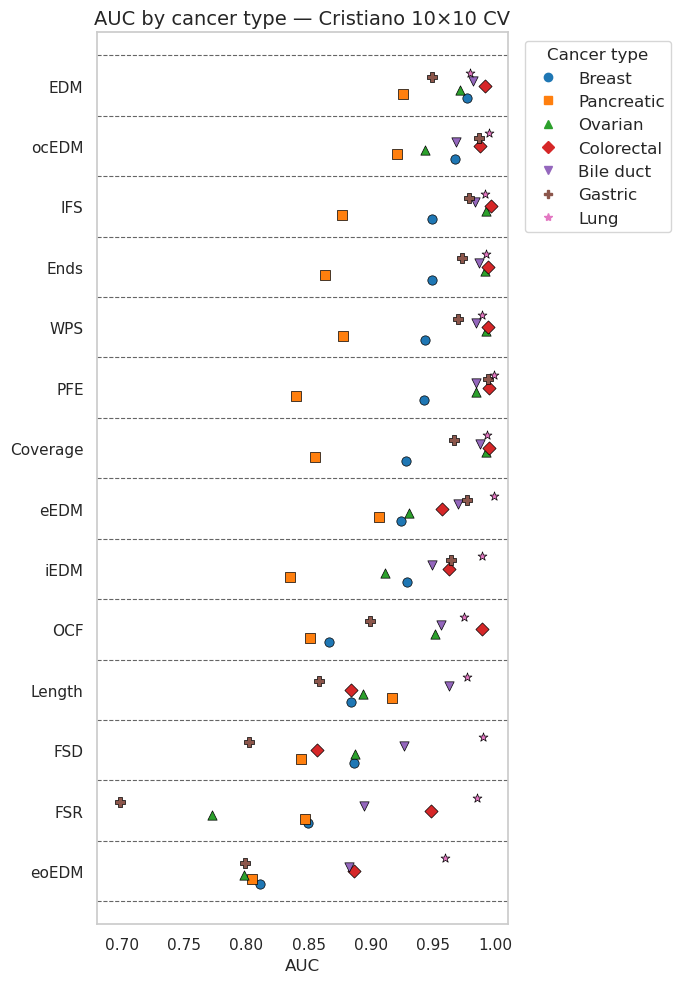

In [123]:
# B — Forest plot: per-feature AUC by cancer type (Cristiano 10×10 CV)
from matplotlib.lines import Line2D

feat_order_f = [d['name'] for d in cv_roc]  # AUC desc

cancer_types_f = (cancer_type_auc_df.groupby('cancer_type')['n']
                  .first().sort_values(ascending=False).index.tolist())
short_ct = {ct: CANCER_RENAME.get(ct, ct) for ct in cancer_types_f}

marker_pool = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p']
type_markers = {ct: marker_pool[i % len(marker_pool)] for i, ct in enumerate(cancer_types_f)}
type_pal = sns.color_palette('tab10', len(cancer_types_f))
type_colors = {ct: type_pal[i] for i, ct in enumerate(cancer_types_f)}

n_feats = len(feat_order_f)
n_types = len(cancer_types_f)
y_spread = 0.07

fig, ax = plt.subplots(figsize=(7, 10))
for i, feat in enumerate(feat_order_f):
    y = n_feats - 1 - i
    feat_data = cancer_type_auc_df[cancer_type_auc_df['feature'] == feat]
    for j, ct in enumerate(cancer_types_f):
        row = feat_data[feat_data['cancer_type'] == ct]
        if row.empty:
            continue
        jitter = (j - (n_types - 1) / 2) * y_spread
        ax.scatter(row['auc'].values[0], y + jitter,
                   color=type_colors[ct], marker=type_markers[ct],
                   s=45, zorder=3, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(n_feats))
ax.set_yticklabels(feat_order_f[::-1])
ax.set_xlim(0.68, 1.01)
ax.set_xlabel('AUC')
ax.set_title('AUC by cancer type — Cristiano 10×10 CV', fontsize=14)
ct_handles = [Line2D([0], [0], marker=type_markers[ct], color=type_colors[ct],
                     linestyle='None', markersize=6, label=short_ct[ct])
              for ct in cancer_types_f]
ax.legend(handles=ct_handles, title='Cancer type',
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)
ax.xaxis.grid(False)
ax.yaxis.grid(False)
for sep in [k + 0.5 for k in range(-1, n_feats)]:
    ax.axhline(sep, color='#656565', linewidth=0.8, zorder=0, linestyle='--')
plt.tight_layout()
plt.savefig('scripts/analysis/figures/B_forest_cancer_type_cv.png', bbox_inches='tight')
plt.show()


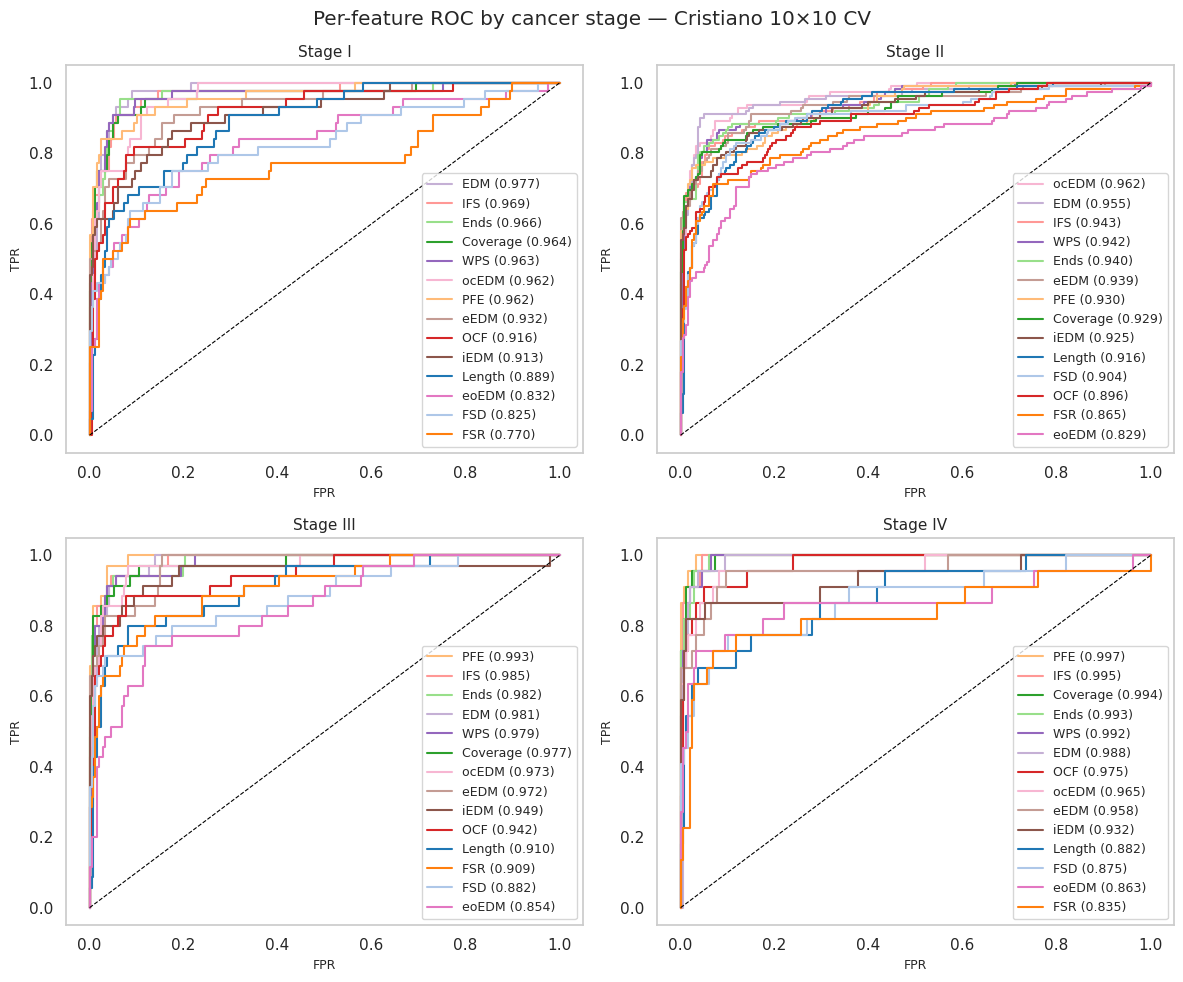

In [124]:
# C — Per-feature ROC by cancer stage, 2×2 grid (Cristiano 10×10 CV)
stage_list = ['I', 'II', 'III', 'IV']

stage_roc = {stage: [] for stage in stage_list}
for feat in FEATURE_NAMES:
    path = cv_dir + f"{feat}_cv_probs.csv"
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path)[['sample_id', 'probability', 'label']].merge(manifest, on='sample_id', how='left')
    healthy_f = df[df['disease'] == 'Healthy']
    for stage in stage_list:
        cancer = df[(df['label'] == 1) & (df['stage'] == stage)]
        if len(cancer) == 0:
            continue
        subset = pd.concat([cancer, healthy_f])
        fpr, tpr, _ = roc_curve(subset['label'], subset['probability'])
        auc = roc_auc_score(subset['label'], subset['probability'])
        stage_roc[stage].append({'name': RENAME.get(feat, feat), 'fpr': fpr, 'tpr': tpr, 'auc': auc})

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, stage in zip(axes.flatten(), stage_list):
    n_cancer = sum(len(d['fpr']) > 0 for d in stage_roc[stage])
    sorted_stage_roc = sorted(stage_roc[stage], key=lambda d: d['auc'], reverse=True)
    for d in sorted_stage_roc:
        ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']), lw=1.5,
                label=f"{d['name']} ({d['auc']:.3f})")
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_title(f"Stage {stage}", fontsize=11)
    ax.set_xlabel('FPR', fontsize=9); ax.set_ylabel('TPR', fontsize=9)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(False)
plt.suptitle('Per-feature ROC by cancer stage — Cristiano 10×10 CV')
plt.tight_layout()
plt.savefig('scripts/analysis/figures/B_roc_stage_feat_2x2.png', bbox_inches='tight')
plt.show()

## C — Cristiano ensemble

In [125]:
ens_dir = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/ensemble_nostd/cv/"
ens_df  = pd.read_csv(ens_dir + "cv_probs.csv").rename(columns={'Unnamed: 0': 'sample_id'})

ens_fpr, ens_tpr, _ = roc_curve(ens_df['label'], ens_df['probability'])
ens_auc  = roc_auc_score(ens_df['label'], ens_df['probability'])
ens_merge = ens_df[['sample_id', 'probability', 'label']].merge(manifest, on='sample_id', how='left')

cancer_types = (ens_merge[ens_merge['label'] == 1]['disease']
                .value_counts().loc[lambda s: s >= 5].index.tolist())
healthy  = ens_merge[ens_merge['disease'] == 'Healthy']
panels   = ['All cancers'] + cancer_types
type_aucs = {ct: roc_auc_score(
                pd.concat([ens_merge[ens_merge['disease'] == ct], healthy])['label'],
                pd.concat([ens_merge[ens_merge['disease'] == ct], healthy])['probability'])
             for ct in cancer_types}
type_ns = {ct: len(ens_merge[ens_merge['disease'] == ct]) for ct in cancer_types}
print(f"Ensemble AUC: {ens_auc:.4f}  (n={len(ens_df)})")


Ensemble AUC: 0.9918  (n=459)


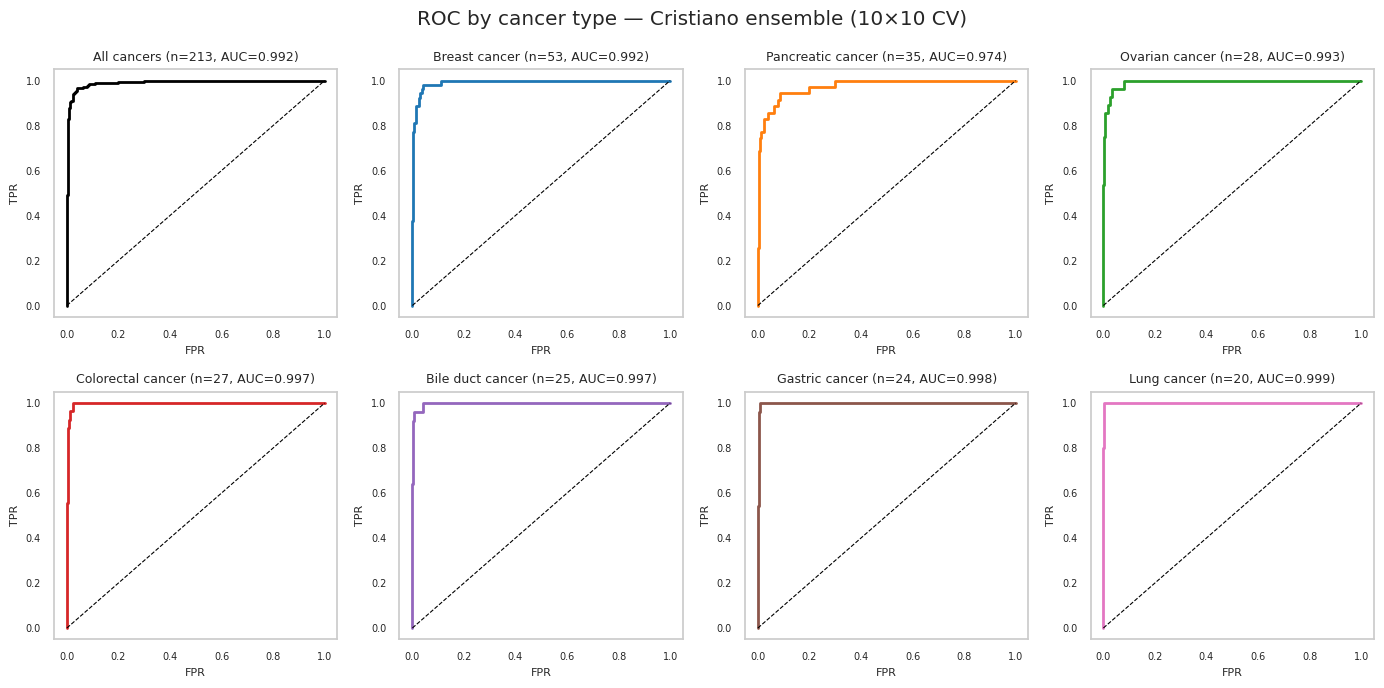

In [126]:
# 2×4 
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, panel in zip(axes.flatten(), panels):
    if panel == 'All cancers':
        cancer = ens_merge[ens_merge['label'] == 1]
    else:
        cancer = ens_merge[ens_merge['disease'] == panel]
    subset = pd.concat([cancer, healthy])
    fpr_t, tpr_t, thresholds = roc_curve(subset['label'], subset['probability'])
    auc_t = roc_auc_score(subset['label'], subset['probability'])
    color = type_colors.get(panel, 'black')
    ax.plot(fpr_t, tpr_t, color=color, lw=2)
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_title(f"{panel} (n={len(cancer)}, AUC={auc_t:.3f})", fontsize=9)
    ax.set_xlabel('FPR', fontsize=8); ax.set_ylabel('TPR', fontsize=8)
    ax.tick_params(labelsize=7)
plt.suptitle('ROC by cancer type — Cristiano ensemble (10×10 CV)')
for ax in axes.flatten(): ax.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/C12b_roc_cancer_type_2x4.png", bbox_inches='tight')
plt.show()

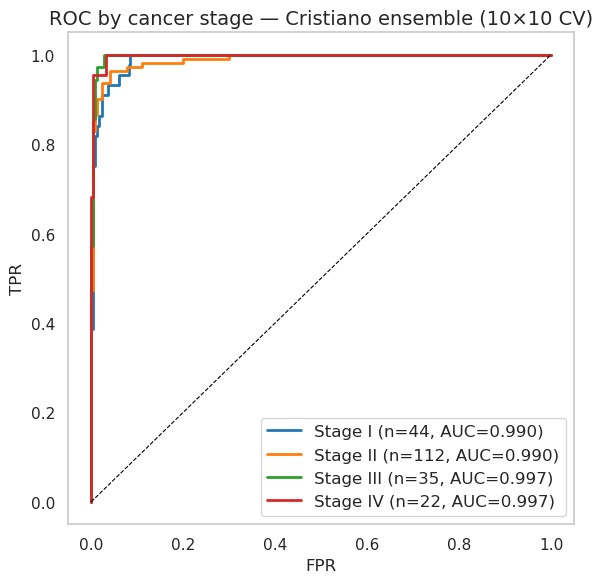

In [127]:
stage_colors = {'I': '#1f77b4', 'II': '#ff7f0e', 'III': '#2ca02c', 'IV': '#d62728'}
healthy_ens  = ens_merge[ens_merge['disease'] == 'Healthy']

fig, ax = plt.subplots(figsize=(6, 6))
for stage in ['I', 'II', 'III', 'IV']:
    cancer = ens_merge[(ens_merge['label'] == 1) & (ens_merge['stage'] == stage)]
    if len(cancer) == 0:
        continue
    subset = pd.concat([cancer, healthy_ens])
    fpr_s, tpr_s, thresholds = roc_curve(subset['label'], subset['probability'])
    auc_s = roc_auc_score(subset['label'], subset['probability'])
    ax.plot(fpr_s, tpr_s, color=stage_colors[stage], lw=2,
            label=f"Stage {stage} (n={len(cancer)}, AUC={auc_s:.3f})")
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC by cancer stage — Cristiano ensemble (10×10 CV)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/C13_roc_stage_ensemble.png", bbox_inches='tight')
plt.show()

/tmp/ipykernel_2616392/2305030163.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2616392/2305030163.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


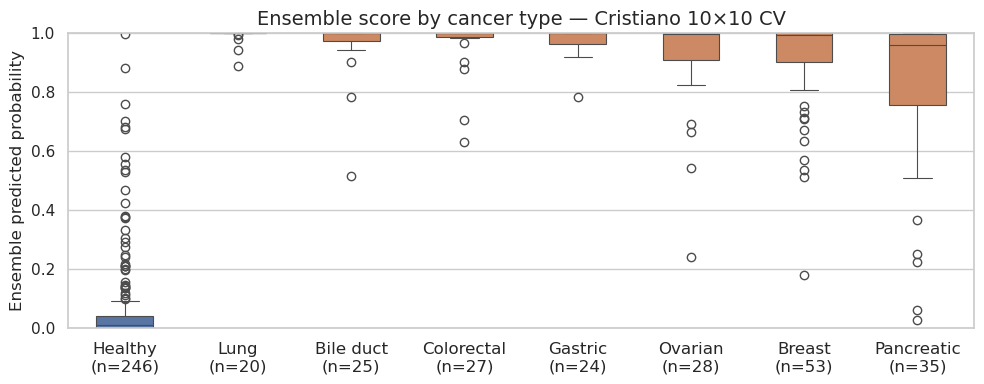

In [128]:
# C — Ensemble score by cancer type
exclude = {'Duodenal cancer'}  # n=1
ct_df = ens_merge[~ens_merge['disease'].isin(exclude)]

cancer_medians = (
    ct_df[ct_df['label'] == 1]
    .groupby('disease')['probability'].median()
    .sort_values(ascending=False)
)
order =  ['Healthy'] + cancer_medians.index.tolist()
palette = {t: old_palette[1] for t in cancer_medians.index}
palette['Healthy'] = old_palette[0]
ns = ct_df.groupby('disease')['sample_id'].count()

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(
    data=ct_df, x='disease', y='probability',
    order=order, palette=palette,
    width=0.5, linewidth=0.8,
)
ax.set_xticklabels(
    [f"{CANCER_RENAME.get(t, t)}\n(n={ns.get(t, 0)})" for t in order],
    fontsize=12
)
ax.set_ylim(0, 1)
ax.set_xlabel('')
ax.set_ylabel('Ensemble predicted probability')
ax.set_title('Ensemble score by cancer type — Cristiano 10×10 CV', fontsize=14)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('scripts/analysis/figures/C_score_by_cancer_type.png', bbox_inches='tight')
plt.show()

## D — External validation (Cristiano-trained)

In [129]:
ly_test_dir = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/prevelynch_test/"
gs_test_dir = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/genoscan/"

cr_ly_roc = load_roc_data(ly_test_dir)
cr_gs_roc = load_roc_data(gs_test_dir)

names_ly = [d['name'] for d in cr_ly_roc]; aucs_ly = [d['auc'] for d in cr_ly_roc]
names_gs = [d['name'] for d in cr_gs_roc]; aucs_gs = [d['auc'] for d in cr_gs_roc]

ens_cr_ly_df  = pd.read_csv('data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/ensemble_nostd/test/ensemble_nostd/test/prevelynch_test_preds.csv')
ens_cr_gs_df  = pd.read_csv('data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/ensemble_nostd/test/ensemble_nostd/test/genoscan_preds.csv')
ens_cr_ly_auc = roc_auc_score(ens_cr_ly_df['label'], ens_cr_ly_df['probability'])
ens_cr_gs_auc = roc_auc_score(ens_cr_gs_df['label'], ens_cr_gs_df['probability'])


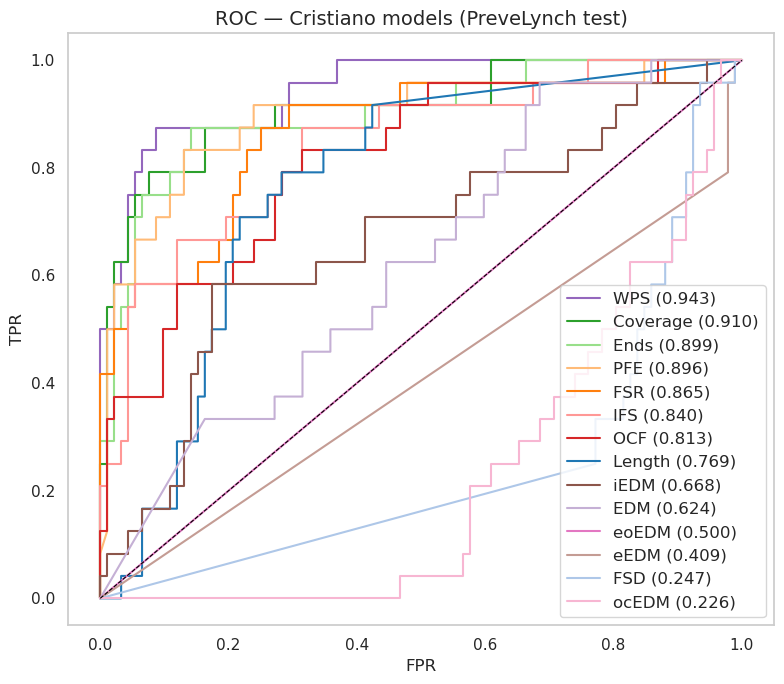

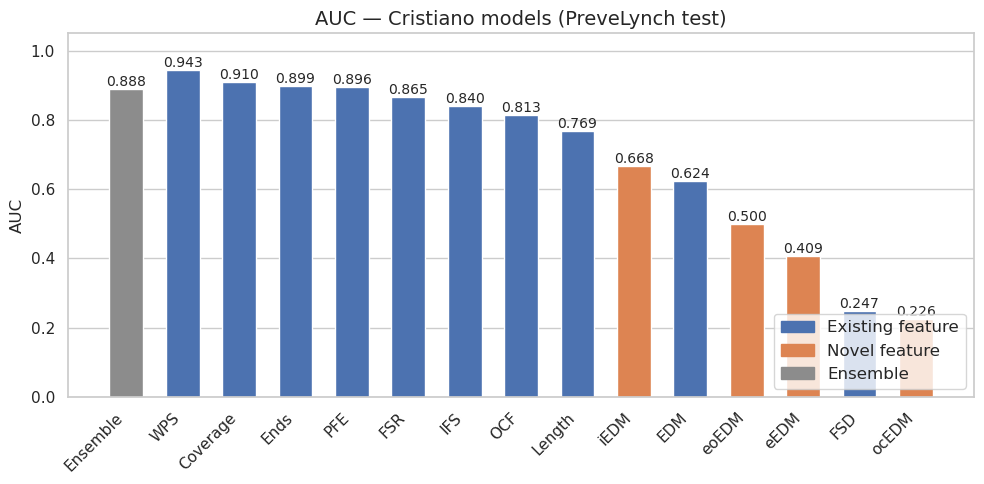

In [130]:
# D14 — Cristiano → PreveLynch ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
for d in cr_ly_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — Cristiano models (PreveLynch test)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D14_roc_crist_ly.png", bbox_inches='tight')
plt.show()

ENS_BAR_COLOR = old_palette[7]
_names  = ['Ensemble'] + names_ly
_aucs   = [ens_cr_ly_auc] + aucs_ly
_colors = [ENS_BAR_COLOR] + [is_new_color(n) for n in names_ly]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(_names)), _aucs, color=_colors, width=0.6)
ax.set_xticks(range(len(_names))); ax.set_xticklabels(_names, rotation=45, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — Cristiano models (PreveLynch test)', fontsize=14)
ax.legend(handles=[Patch(color=old_palette[0], label='Existing feature'),
                   Patch(color=old_palette[1], label='Novel feature'),
                   Patch(color=ENS_BAR_COLOR,  label='Ensemble')],
          loc='lower right', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D14b_auc_crist_ly.png", bbox_inches='tight')
plt.show()


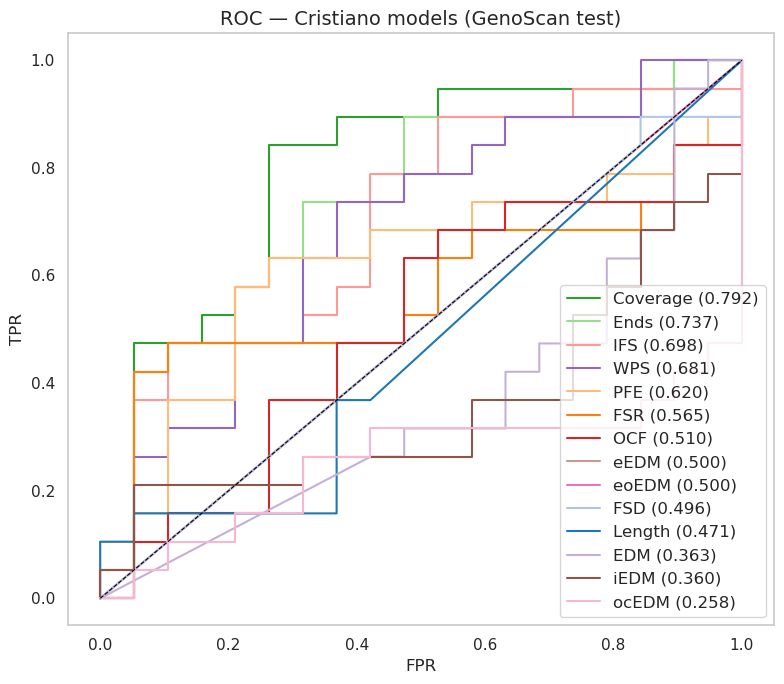

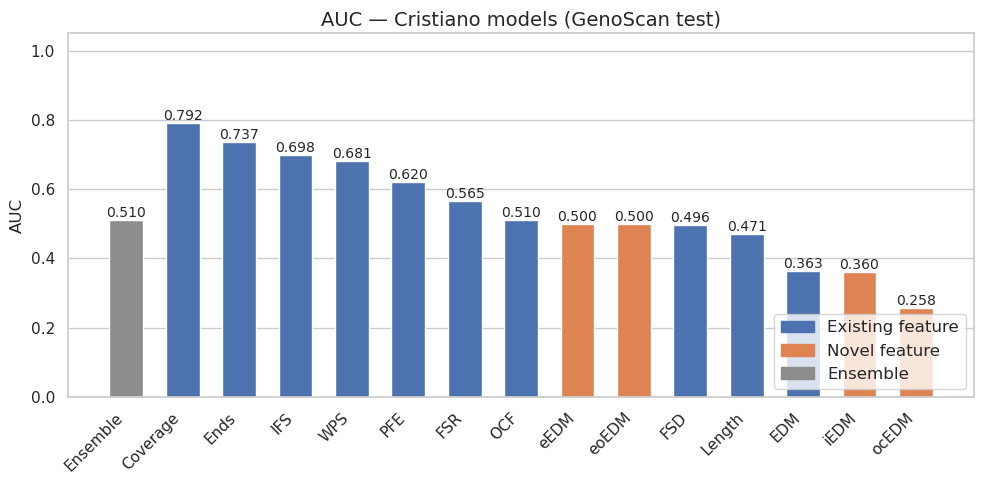

In [131]:
# D15 — Cristiano train, GenoScan test ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
for d in cr_gs_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — Cristiano models (GenoScan test)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D15_roc_crist_gs.png", bbox_inches='tight')
plt.show()

ENS_BAR_COLOR = old_palette[7]
_names  = ['Ensemble'] + names_gs
_aucs   = [ens_cr_gs_auc] + aucs_gs
_colors = [ENS_BAR_COLOR] + [is_new_color(n) for n in names_gs]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(_names)), _aucs, color=_colors, width=0.6)
ax.set_xticks(range(len(_names))); ax.set_xticklabels(_names, rotation=45, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — Cristiano models (GenoScan test)', fontsize=14)
ax.legend(handles=[Patch(color=old_palette[0], label='Existing feature'),
                   Patch(color=old_palette[1], label='Novel feature'),
                   Patch(color=ENS_BAR_COLOR,  label='Ensemble')],
          loc='lower right', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D15b_auc_crist_gs.png", bbox_inches='tight')
plt.show()


## D — Cristiano ensemble external validation

In [132]:
ens_test_base = 'data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/ensemble_nostd/test/ensemble_nostd/test/'

cr_ens_ly_df = pd.read_csv(ens_test_base + 'prevelynch_test_preds.csv')
cr_ens_ly_fpr, cr_ens_ly_tpr, thresholds = roc_curve(cr_ens_ly_df['label'], cr_ens_ly_df['probability'])
cr_ens_ly_auc = roc_auc_score(cr_ens_ly_df['label'], cr_ens_ly_df['probability'])

cr_ens_gs_df = pd.read_csv(ens_test_base + 'genoscan_preds.csv')
cr_ens_gs_fpr, cr_ens_gs_tpr, thresholds = roc_curve(cr_ens_gs_df['label'], cr_ens_gs_df['probability'])
cr_ens_gs_auc = roc_auc_score(cr_ens_gs_df['label'], cr_ens_gs_df['probability'])

print(f'Cristiano ensemble AUC (PreveLynch test): {cr_ens_ly_auc:.4f}  (n={len(cr_ens_ly_df)})')
print(f'Cristiano ensemble AUC (GenoScan test): {cr_ens_gs_auc:.4f}  (n={len(cr_ens_gs_df)})')


Cristiano ensemble AUC (PreveLynch test): 0.8881  (n=116)
Cristiano ensemble AUC (GenoScan test): 0.5097  (n=38)


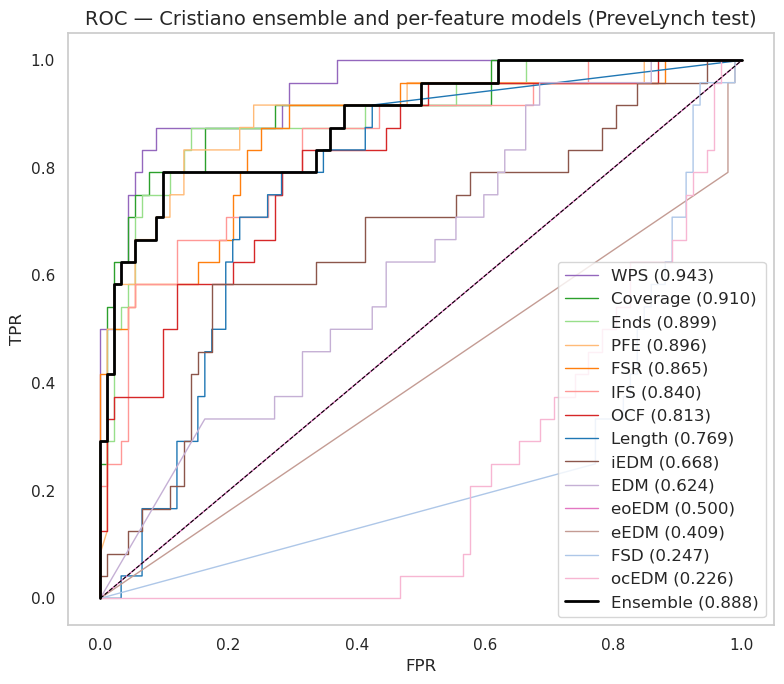

In [133]:
# D — Cristiano ensemble → PreveLynch ROC
fig, ax = plt.subplots(figsize=(8, 7))
for d in cr_ly_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']), linewidth=1,alpha=1,
            label=f"{d['name']} ({d['auc']:.3f})")
ax.plot(cr_ens_ly_fpr, cr_ens_ly_tpr, color='black', linewidth=2,
        label=f'Ensemble ({cr_ens_ly_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — Cristiano ensemble and per-feature models (PreveLynch test)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.savefig('scripts/analysis/figures/D_crist_ens_roc_ly.png', bbox_inches='tight')
plt.show()

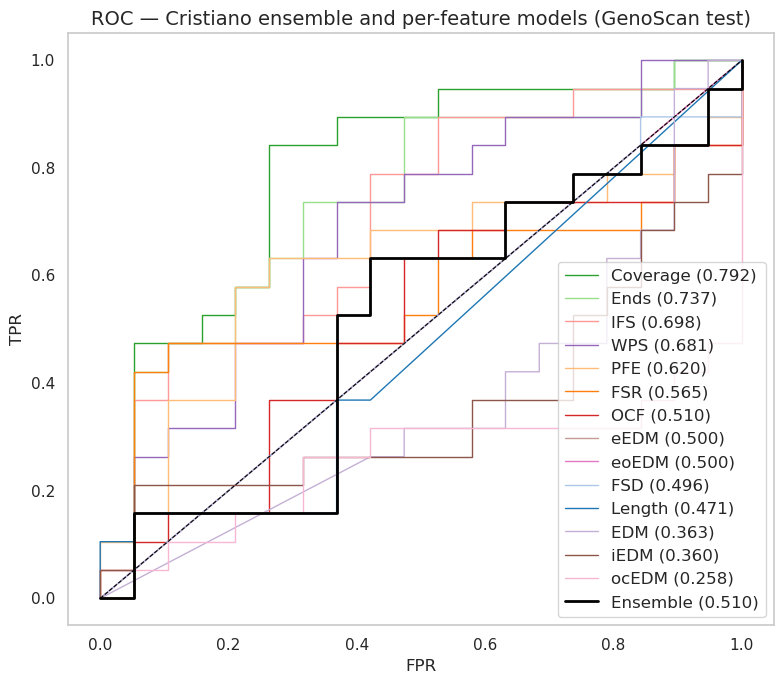

In [134]:
# D — Cristiano ensemble → GenoScan ROC
fig, ax = plt.subplots(figsize=(8, 7))
for d in cr_gs_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']), linewidth=1, alpha=1,
            label=f"{d['name']} ({d['auc']:.3f})")
ax.plot(cr_ens_gs_fpr, cr_ens_gs_tpr, color='black', linewidth=2,
        label=f'Ensemble ({cr_ens_gs_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — Cristiano ensemble and per-feature models (GenoScan test)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.savefig('scripts/analysis/figures/D_crist_ens_roc_gs.png', bbox_inches='tight')
plt.show()

## D (LY-trained) — LY CV and external test
Note: LY cohort contains only CRC + controls — no cancer-type grid.

### 1×10 CV

In [135]:
ly_cv_dir = "data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_cv1_mapq30_v2/cv/"
ly_ly_dir = "data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_cv1_mapq30_v2/test/prevelynch_test/"
ly_gs_dir = "data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_cv1_mapq30_v2/test/genoscan/"

ly_cv_roc = load_roc_data(ly_cv_dir, suffix='_cv_probs.csv')
ly_ly_roc = load_roc_data(ly_ly_dir)
ly_gs_roc = load_roc_data(ly_gs_dir)

names_ly_cv = [d['name'] for d in ly_cv_roc]; aucs_ly_cv = [d['auc'] for d in ly_cv_roc]
names_ly_ly = [d['name'] for d in ly_ly_roc]; aucs_ly_ly = [d['auc'] for d in ly_ly_roc]
names_ly_gs = [d['name'] for d in ly_gs_roc]; aucs_ly_gs = [d['auc'] for d in ly_gs_roc]

ens_ly_cv_df  = pd.read_csv('data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_cv1_mapq30_v2/ensemble_nostd/cv/cv_probs.csv')
ens_ly_cv_auc = roc_auc_score(ens_ly_cv_df['label'], ens_ly_cv_df['probability'])
ens_ly_cv_fpr, ens_ly_cv_tpr, _ = roc_curve(ens_ly_cv_df['label'], ens_ly_cv_df['probability'])

ens_ly_cv1_ly_df  = pd.read_csv('data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_cv1_mapq30_v2/ensemble_nostd/test/prevelynch_test_preds.csv')
ens_ly_cv1_gs_df  = pd.read_csv('data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_cv1_mapq30_v2/ensemble_nostd/test/genoscan_preds.csv')
ens_ly_cv1_ly_auc = roc_auc_score(ens_ly_cv1_ly_df['label'], ens_ly_cv1_ly_df['probability'])
ens_ly_cv1_gs_auc = roc_auc_score(ens_ly_cv1_gs_df['label'], ens_ly_cv1_gs_df['probability'])
ens_ly_cv1_ly_fpr, ens_ly_cv1_ly_tpr, _ = roc_curve(ens_ly_cv1_ly_df['label'], ens_ly_cv1_ly_df['probability'])
ens_ly_cv1_gs_fpr, ens_ly_cv1_gs_tpr, _ = roc_curve(ens_ly_cv1_gs_df['label'], ens_ly_cv1_gs_df['probability'])


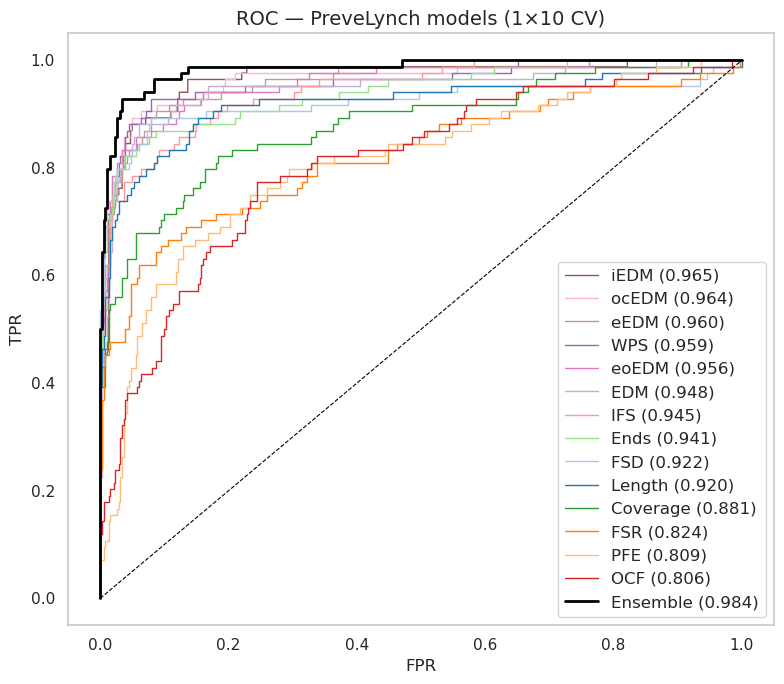

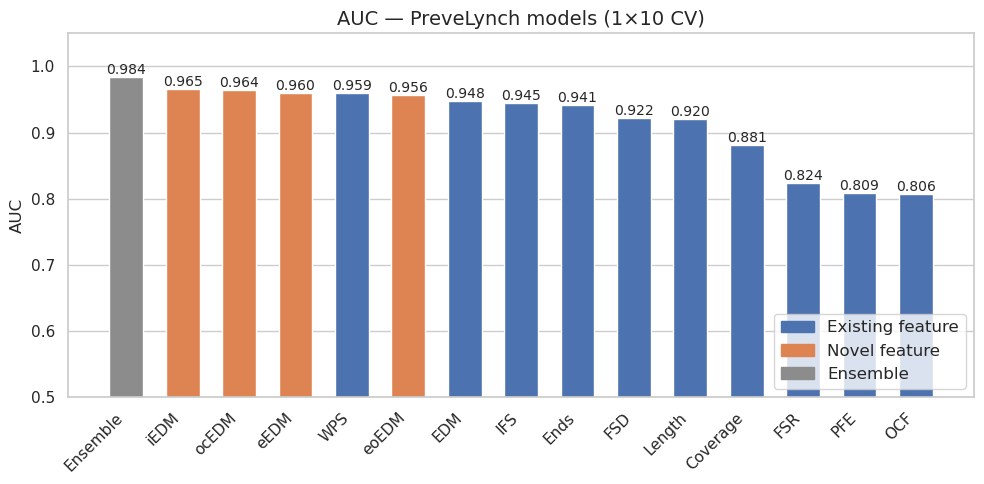

In [136]:
# D19 — PreveLynch CV ROC + AUC bars
ENS_BAR_COLOR = old_palette[7]
fig, ax = plt.subplots(figsize=(8, 7))
for d in ly_cv_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1)
ax.plot(ens_ly_cv_fpr, ens_ly_cv_tpr, color='black', lw=2,
        label=f'Ensemble ({ens_ly_cv_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — PreveLynch models (1×10 CV)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D19_roc_ly_cv1.png", bbox_inches='tight')
plt.show()

_names  = ['Ensemble'] + names_ly_cv
_aucs   = [ens_ly_cv_auc] + aucs_ly_cv
_colors = [ENS_BAR_COLOR] + [is_new_color(n) for n in names_ly_cv]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(_names)), _aucs, color=_colors, width=0.6)
ax.set_xticks(range(len(_names))); ax.set_xticklabels(_names, rotation=45, ha='right')
ax.set_ylim(0.5, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — PreveLynch models (1×10 CV)', fontsize=14)
ax.legend(handles=[Patch(color=old_palette[0], label='Existing feature'),
                   Patch(color=old_palette[1], label='Novel feature'),
                   Patch(color=ENS_BAR_COLOR,  label='Ensemble')],
          loc='lower right', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D19b_auc_ly_cv1.png", bbox_inches='tight')
plt.show()


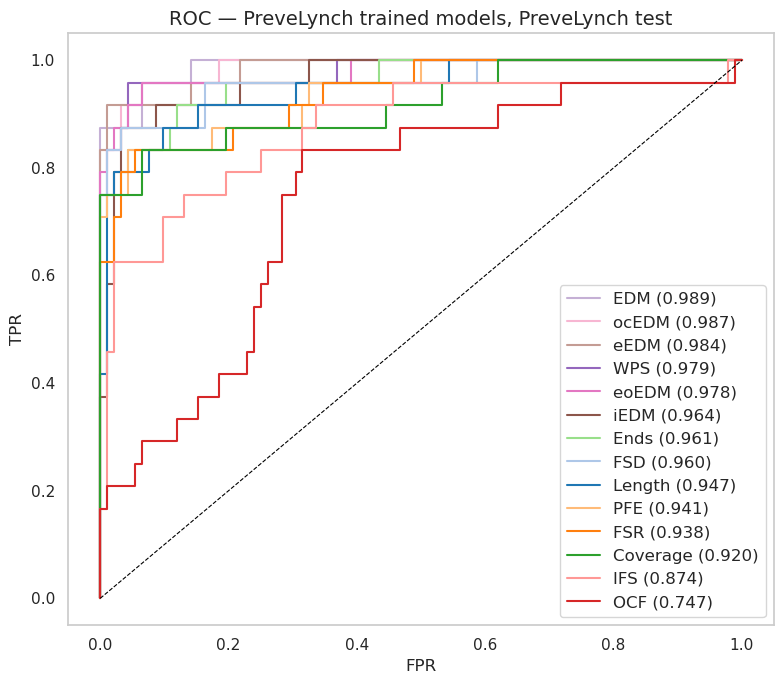

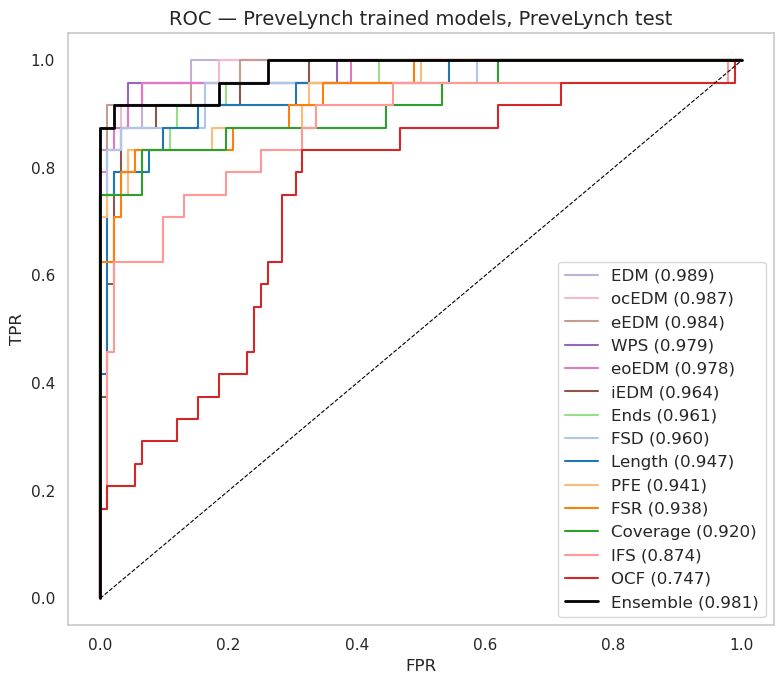

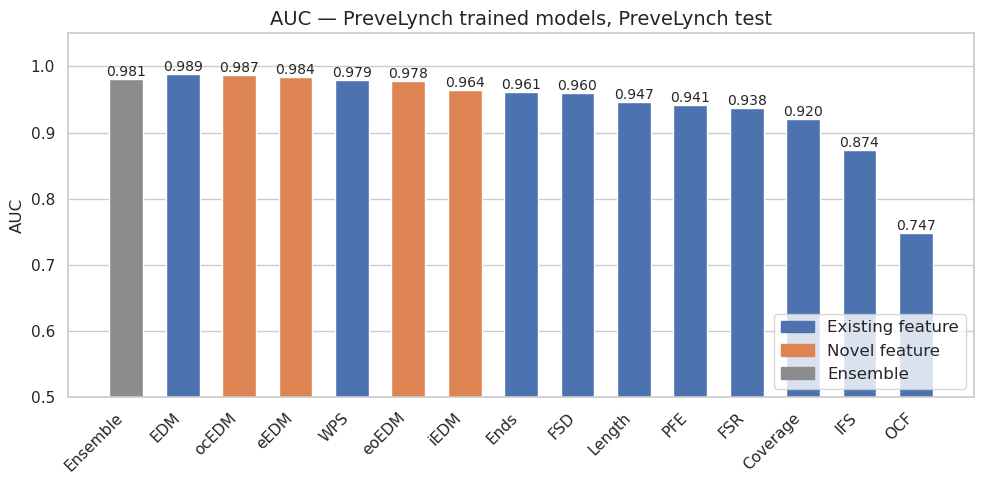

In [137]:
# D20 — PreveLynch trained models, PreveLynch test ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
for d in ly_ly_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — PreveLynch trained models, PreveLynch test', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D20_roc_ly_ly.png", bbox_inches='tight')
plt.show()

# also create a version with ensemble roc curve 
fig, ax = plt.subplots(figsize=(8, 7))
for d in ly_ly_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot(ens_ly_cv1_ly_fpr, ens_ly_cv1_ly_tpr, color='black', linewidth=2,
        label=f'Ensemble ({ens_ly_cv1_ly_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — PreveLynch trained models, PreveLynch test', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D20_roc_ly_ly_ens.png", bbox_inches='tight')
plt.show()



ENS_BAR_COLOR = old_palette[7]
_names  = ['Ensemble'] + names_ly_ly
_aucs   = [ens_ly_cv1_ly_auc] + aucs_ly_ly
_colors = [ENS_BAR_COLOR] + [is_new_color(n) for n in names_ly_ly]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(_names)), _aucs, color=_colors, width=0.6)
ax.set_xticks(range(len(_names))); ax.set_xticklabels(_names, rotation=45, ha='right')
ax.set_ylim(0.5, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — PreveLynch trained models, PreveLynch test', fontsize=14)
ax.legend(handles=[Patch(color=old_palette[0], label='Existing feature'),
                   Patch(color=old_palette[1], label='Novel feature'),
                   Patch(color=ENS_BAR_COLOR,  label='Ensemble')],
          loc='lower right', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D20b_auc_ly_ly.png", bbox_inches='tight')
plt.show()


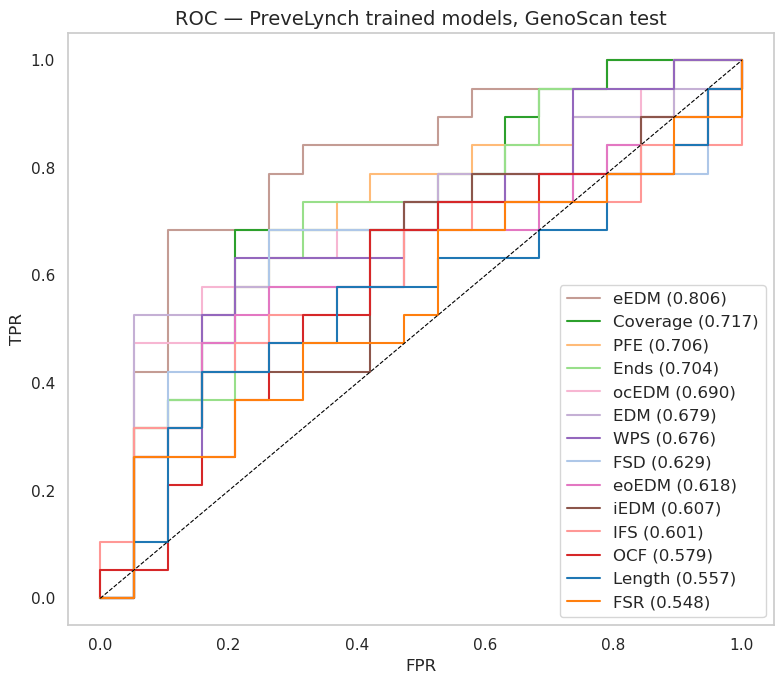

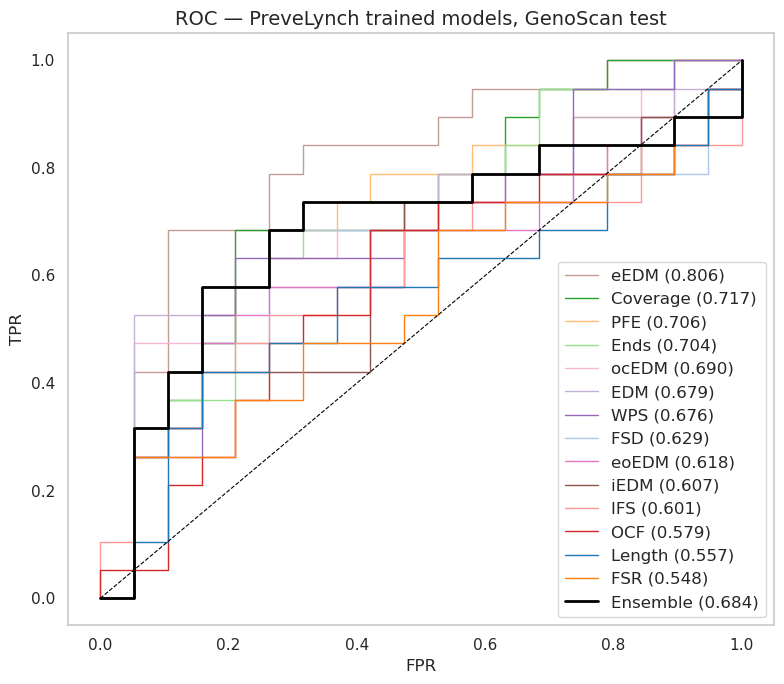

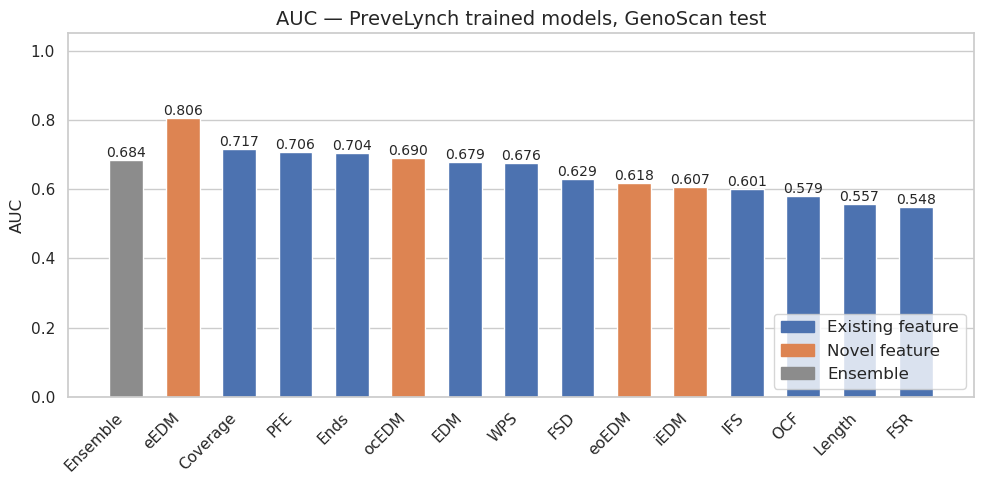

In [138]:
# D21 — PreveLynch trained models, GenoScan test ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
for d in ly_gs_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — PreveLynch trained models, GenoScan test', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D21_roc_ly_gs.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
for d in ly_gs_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']), linewidth=1, alpha=1,
            label=f"{d['name']} ({d['auc']:.3f})")
ax.plot(ens_ly_cv1_gs_fpr, ens_ly_cv1_gs_tpr, color='black', linewidth=2,
        label=f'Ensemble ({ens_ly_cv1_gs_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — PreveLynch trained models, GenoScan test', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D21_roc_ly_gs_ens.png", bbox_inches='tight')
plt.show()

ENS_BAR_COLOR = old_palette[7]
_names  = ['Ensemble'] + names_ly_gs
_aucs   = [ens_ly_cv1_gs_auc] + aucs_ly_gs
_colors = [ENS_BAR_COLOR] + [is_new_color(n) for n in names_ly_gs]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(_names)), _aucs, color=_colors, width=0.6)
ax.set_xticks(range(len(_names))); ax.set_xticklabels(_names, rotation=45, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — PreveLynch trained models, GenoScan test', fontsize=14)
ax.legend(handles=[Patch(color=old_palette[0], label='Existing feature'),
                   Patch(color=old_palette[1], label='Novel feature'),
                   Patch(color=ENS_BAR_COLOR,  label='Ensemble')],
          loc='lower right', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D21b_auc_ly_gs.png", bbox_inches='tight')
plt.show()


### 1×10 CV

In [139]:
ly_cv1_dir = 'data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_cv1_mapq30_v2/cv/'
ly_cv1_roc = load_roc_data(ly_cv1_dir, suffix='_cv_probs.csv')
names_ly_cv1 = [d['name'] for d in ly_cv1_roc]
aucs_ly_cv1  = [d['auc']  for d in ly_cv1_roc]

ens_ly_cv1_ly_df  = pd.read_csv('data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_cv1_mapq30_v2/ensemble_nostd/test/prevelynch_test_preds.csv')
ens_ly_cv1_gs_df  = pd.read_csv('data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_cv1_mapq30_v2/ensemble_nostd/test/genoscan_preds.csv')
ens_ly_cv1_ly_auc = roc_auc_score(ens_ly_cv1_ly_df['label'], ens_ly_cv1_ly_df['probability'])
ens_ly_cv1_gs_auc = roc_auc_score(ens_ly_cv1_gs_df['label'], ens_ly_cv1_gs_df['probability'])

ens_test_base = 'data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_cv1_mapq30_v2/ensemble_nostd/test/'

ly_ens_ly_df = pd.read_csv(ens_test_base + 'prevelynch_test_preds.csv')
ly_ens_ly_fpr, ly_ens_ly_tpr, thresholds = roc_curve(ly_ens_ly_df['label'], ly_ens_ly_df['probability'])
ly_ens_ly_auc = roc_auc_score(ly_ens_ly_df['label'], ly_ens_ly_df['probability'])

ly_ens_gs_df = pd.read_csv(ens_test_base + 'genoscan_preds.csv')
ly_ens_gs_fpr, ly_ens_gs_tpr, thresholds = roc_curve(ly_ens_gs_df['label'], ly_ens_gs_df['probability'])
ly_ens_gs_auc = roc_auc_score(ly_ens_gs_df['label'], ly_ens_gs_df['probability'])

print(f'PreveLynch ensemble AUC (PreveLynch test): {ly_ens_ly_auc:.4f}  (n={len(ly_ens_ly_df)})')
print(f'PreveLynch ensemble AUC (GenoScan test): {ly_ens_gs_auc:.4f}  (n={len(ly_ens_gs_df)})')

PreveLynch ensemble AUC (PreveLynch test): 0.9805  (n=116)
PreveLynch ensemble AUC (GenoScan test): 0.6842  (n=38)


PreveLynch 1×10 CV ensemble AUC: 0.9835  (n=465)


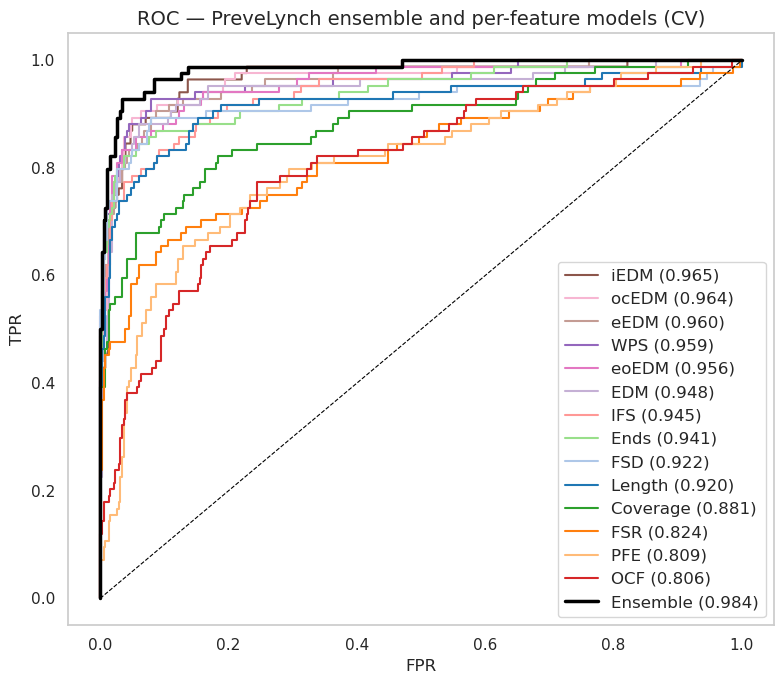

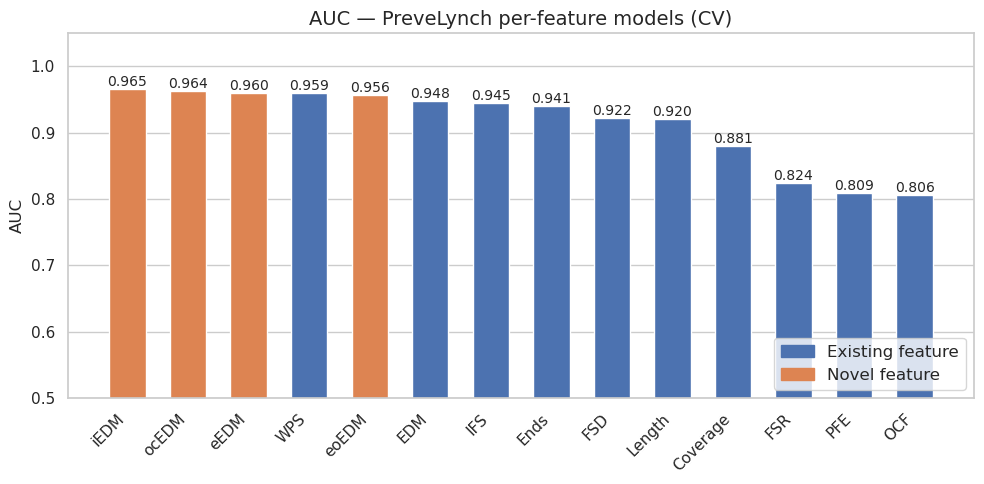

In [140]:
# D — PreveLynch 1×10 CV ensemble ROC + per-feature AUC bars
ly_cv1_ens_dir = 'data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_cv1_mapq30_v2/ensemble_nostd/cv/'
ly_cv1_ens_df = pd.read_csv(ly_cv1_ens_dir + 'cv_probs.csv').rename(columns={'Unnamed: 0': 'sample_id'})
ly_cv1_ens_fpr, ly_cv1_ens_tpr, thresholds = roc_curve(ly_cv1_ens_df['label'], ly_cv1_ens_df['probability'])
ly_cv1_ens_auc = roc_auc_score(ly_cv1_ens_df['label'], ly_cv1_ens_df['probability'])
print(f'PreveLynch 1×10 CV ensemble AUC: {ly_cv1_ens_auc:.4f}  (n={len(ly_cv1_ens_df)})')

fig, ax = plt.subplots(figsize=(8, 7))
for d in ly_cv1_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']), linewidth=1.5, alpha=1,
            label=f"{d['name']} ({d['auc']:.3f})")
ax.plot(ly_cv1_ens_fpr, ly_cv1_ens_tpr, color='black', linewidth=2.5,
        label=f'Ensemble ({ly_cv1_ens_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — PreveLynch ensemble and per-feature models (CV)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.savefig('scripts/analysis/figures/D_ly_cv1_ens_roc.png', bbox_inches='tight')
plt.show()

_colors = [is_new_color(n) for n in names_ly_cv1]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(names_ly_cv1)), aucs_ly_cv1, color=_colors, width=0.6)
ax.set_xticks(range(len(names_ly_cv1))); ax.set_xticklabels(names_ly_cv1, rotation=45, ha='right')
ax.set_ylim(0.5, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — PreveLynch per-feature models (CV)', fontsize=14)
ax.legend(handles=[Patch(color=old_palette[0], label='Existing feature'),
                   Patch(color=old_palette[1], label='Novel feature')],
          loc='lower right', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('scripts/analysis/figures/D_ly_cv1_auc.png', bbox_inches='tight')
plt.show()


## D (CRC-trained) — CRC CV and external test
Note: CRC cohort contains only Colorectal cancer + controls.

In [141]:
crc_cv_dir  = "data/matrix_crc/svm_by_feature/svm_linear_pca150.0_gc_mapq30/cv/"
crc_ly_dir  = "data/matrix_crc/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/prevelynch_test/"
crc_gs_dir  = "data/matrix_crc/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/genoscan/"
crc_manifest = pd.read_csv("data/manifest/Cristiano_metadata_crc.csv")[['sample_id', 'disease', 'stage']]

crc_cv_roc = load_roc_data(crc_cv_dir, suffix='_cv_probs.csv')
crc_ly_roc = load_roc_data(crc_ly_dir)
crc_gs_roc = load_roc_data(crc_gs_dir)

names_crc_cv = [d['name'] for d in crc_cv_roc]; aucs_crc_cv = [d['auc'] for d in crc_cv_roc]
names_crc_ly = [d['name'] for d in crc_ly_roc]; aucs_crc_ly = [d['auc'] for d in crc_ly_roc]
names_crc_gs = [d['name'] for d in crc_gs_roc]; aucs_crc_gs = [d['auc'] for d in crc_gs_roc]


Missing: ['fsr', 'pfe', 'coverage', 'wps']
Missing: ['fsr']
Missing: ['fsr']


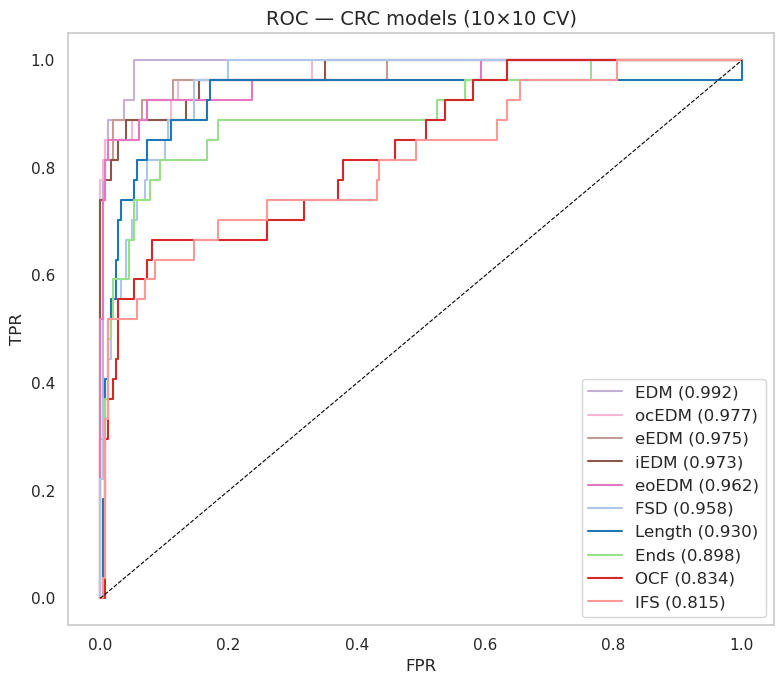

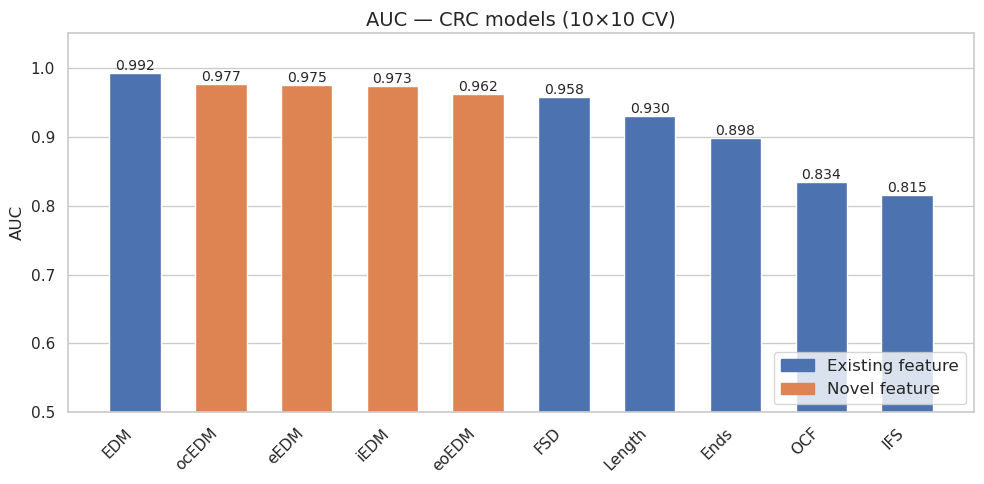

In [142]:
# D16 — CRC CV ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
for d in crc_cv_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — CRC models (10×10 CV)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D16_roc_crc_cv.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(names_crc_cv)), aucs_crc_cv,
        color=[is_new_color(n) for n in names_crc_cv], width=0.6)
ax.set_xticks(range(len(names_crc_cv))); ax.set_xticklabels(names_crc_cv, rotation=45, ha='right')
ax.set_ylim(0.5, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — CRC models (10×10 CV)', fontsize=14)
ax.legend(handles=[Patch(color=old_palette[0], label='Existing feature'),
                   Patch(color=old_palette[1], label='Novel feature')],
          loc='lower right', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D16b_auc_crc_cv.png", bbox_inches='tight')
plt.show()


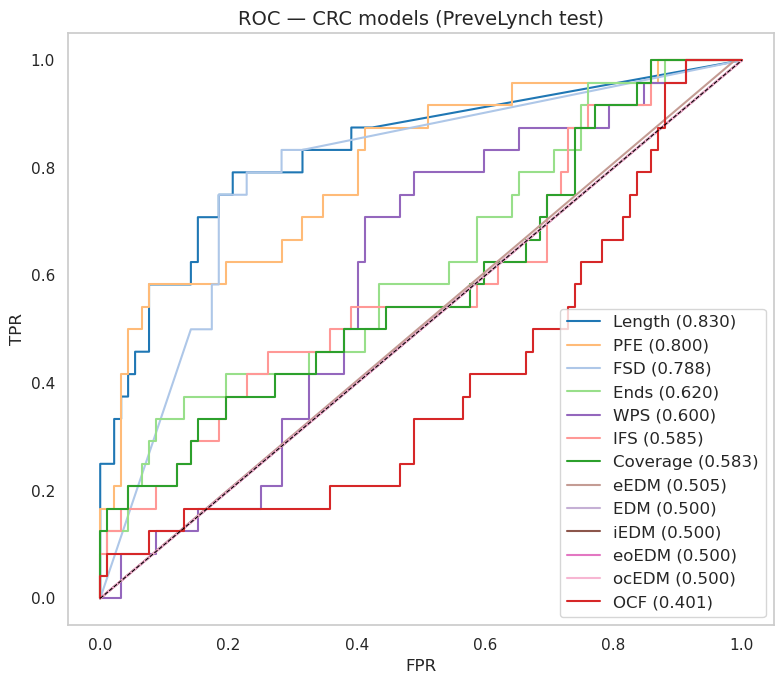

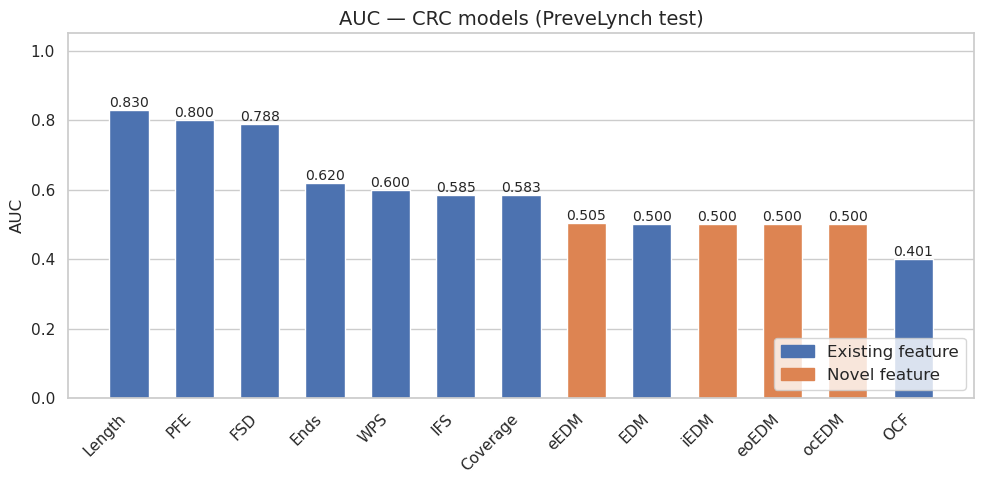

In [143]:
# D17 — CRC models → PreveLynch ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
for d in crc_ly_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — CRC models (PreveLynch test)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D17_roc_crc_ly.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(names_crc_ly)), aucs_crc_ly,
        color=[is_new_color(n) for n in names_crc_ly], width=0.6)
ax.set_xticks(range(len(names_crc_ly))); ax.set_xticklabels(names_crc_ly, rotation=45, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — CRC models (PreveLynch test)', fontsize=14)
ax.legend(handles=[Patch(color=old_palette[0], label='Existing feature'),
                   Patch(color=old_palette[1], label='Novel feature')],
          loc='lower right', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D17b_auc_crc_ly.png", bbox_inches='tight')
plt.show()


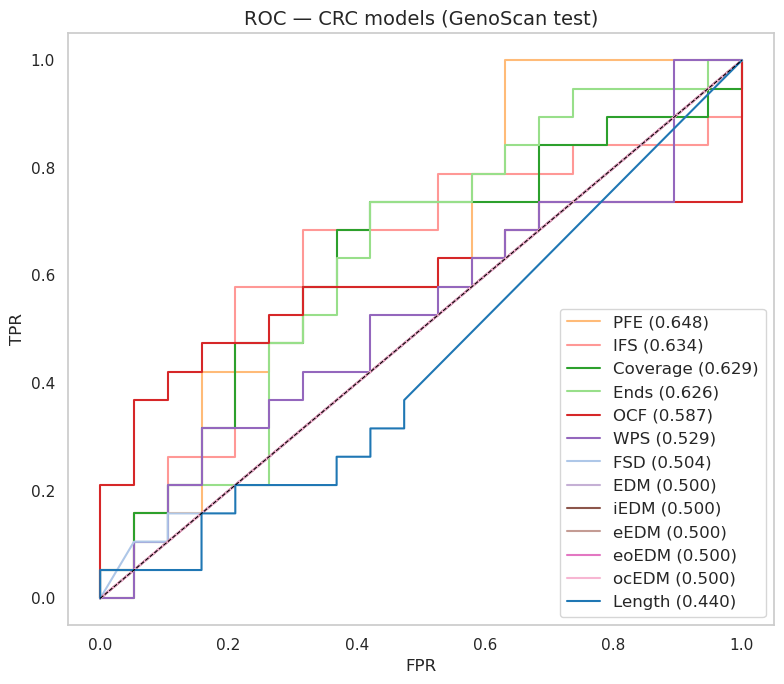

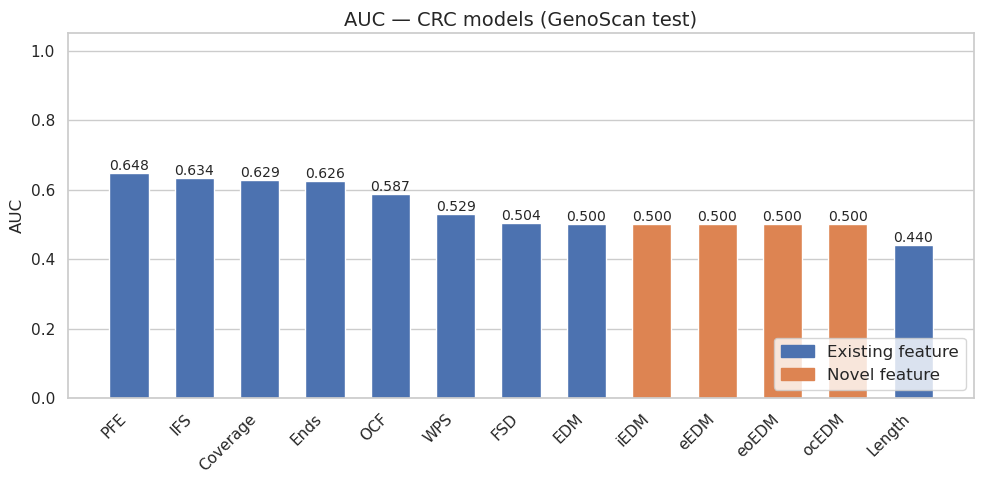

In [144]:
# D18 — CRC models → GenoScan ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
for d in crc_gs_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — CRC models (GenoScan test)', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D18_roc_crc_gs.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(names_crc_gs)), aucs_crc_gs,
        color=[is_new_color(n) for n in names_crc_gs], width=0.6)
ax.set_xticks(range(len(names_crc_gs))); ax.set_xticklabels(names_crc_gs, rotation=45, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — CRC models (GenoScan test)', fontsize=14)
ax.legend(handles=[Patch(color=old_palette[0], label='Existing feature'),
                   Patch(color=old_palette[1], label='Novel feature')],
          loc='lower right', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D18b_auc_crc_gs.png", bbox_inches='tight')
plt.show()


## E — Summary tables

In [145]:
roc_dict_cristiano = {
    'Cristiano CV':             cv_roc,
    'Cristiano models (PreveLynch test)': cr_ly_roc,
    'Cristiano models (GenoScan test)': cr_gs_roc,
}
# roc_dict_ly = {
#     'PreveLynch models (10×10 CV)':      ly_cv_roc,
#     'PreveLynch trained models, PreveLynch test':  ly_ly_roc,
#     'PreveLynch trained models, GenoScan test':  ly_gs_roc,
# }

roc_dict_ly_cv1 = {
    'PreveLynch models (1×10 CV)': ly_cv1_roc,
    'PreveLynch trained models, PreveLynch test':  ly_ly_roc,
    'PreveLynch trained models, GenoScan test':  ly_gs_roc,
}


os.makedirs('scripts/analysis/tables', exist_ok=True)


In [146]:
# E — AUC summary table
auc_table_cristiano = build_auc_table(roc_dict_cristiano).round(4)
auc_table_cristiano.to_csv('scripts/analysis/tables/E_auc_summary_cristiano.csv')
# auc_table_ly = build_auc_table(roc_dict_ly).round(4)
# auc_table_ly.to_csv('scripts/analysis/tables/E_auc_summary_ly.csv')
auc_table_ly_cv1 = build_auc_table(roc_dict_ly_cv1).round(4)
auc_table_ly_cv1.to_csv('scripts/analysis/tables/E_auc_summary_ly_cv1.csv')
display(auc_table_cristiano)
# display(auc_table_ly)
display(auc_table_ly_cv1)


,Cristiano CV,Cristiano models (PreveLynch test),Cristiano models (GenoScan test)
feature,,,
EDM,0.9675,0.6241,0.3629
ocEDM,0.9641,0.2260,0.2576
IFS,0.9604,0.8401,0.6981
Ends,0.9577,0.8990,0.7368
WPS,0.9576,0.9434,0.6814
PFE,0.9540,0.8961,0.6205
Coverage,0.9506,0.9103,0.7922
eEDM,0.9448,0.4085,0.5000
iEDM,0.9273,0.6676,0.3601


,PreveLynch models (1×10 CV),"PreveLynch trained models, PreveLynch test","PreveLynch trained models, GenoScan test"
feature,,,
iEDM,0.9653,0.9642,0.6066
ocEDM,0.9636,0.9869,0.6898
eEDM,0.9604,0.9841,0.8061
WPS,0.9593,0.9787,0.6759
eoEDM,0.9565,0.9778,0.6177
EDM,0.9480,0.9887,0.6787
IFS,0.9451,0.8741,0.6011
Ends,0.9409,0.9611,0.7036
FSD,0.9223,0.9597,0.6288


In [147]:
# E — Sensitivity at fixed specificity (95% and 85%)
sens_table_cristiano = build_sensitivity_table(roc_dict_cristiano, specificities=(0.95, 0.85)).round(4)
sens_table_cristiano.to_csv('scripts/analysis/tables/E_sensitivity_table_cristiano.csv')
display(sens_table_cristiano)
# sens_table_ly = build_sensitivity_table(roc_dict_ly, specificities=(0.95, 0.85)).round(4)
# sens_table_ly.to_csv('scripts/analysis/tables/E_sensitivity_table_ly.csv')
# display(sens_table_ly)
sens_table_ly_cv1 = build_sensitivity_table(roc_dict_ly_cv1, specificities=(0.95, 0.85)).round(4)
sens_table_ly_cv1.to_csv('scripts/analysis/tables/E_sensitivity_table_ly_cv1.csv')
display(sens_table_ly_cv1)


,Cristiano CV_sens95,Cristiano CV_sens85,Cristiano models (PreveLynch test)_sens95,Cristiano models (PreveLynch test)_sens85,Cristiano models (GenoScan test)_sens95,Cristiano models (GenoScan test)_sens85
feature,,,,,,
EDM,0.9155,0.9577,0.0000,0.0000,0.0000,0.0000
ocEDM,0.8216,0.9437,0.0000,0.0000,0.0000,0.1053
IFS,0.8404,0.9202,0.5417,0.6667,0.0000,0.4737
Ends,0.8685,0.9202,0.5833,0.8750,0.0000,0.4737
WPS,0.8592,0.9202,0.7500,0.8750,0.0000,0.3158
PFE,0.8404,0.8873,0.5833,0.8333,0.1053,0.3684
Coverage,0.8498,0.9108,0.7083,0.7917,0.0000,0.4737
eEDM,0.7793,0.8920,0.0000,0.0000,0.0000,0.0000
iEDM,0.7324,0.8545,0.1250,0.4167,0.0526,0.2105


,PreveLynch models (1×10 CV)_sens95,PreveLynch models (1×10 CV)_sens85,"PreveLynch trained models, PreveLynch test_sens95","PreveLynch trained models, PreveLynch test_sens85","PreveLynch trained models, GenoScan test_sens95","PreveLynch trained models, GenoScan test_sens85"
feature,,,,,,
iEDM,0.8810,0.9643,0.8750,0.9167,0.0000,0.3158
ocEDM,0.8929,0.9286,0.9167,0.9583,0.0000,0.4737
eEDM,0.8333,0.9286,0.9167,0.9583,0.0000,0.6842
WPS,0.8810,0.9405,0.9583,0.9583,0.0000,0.2632
eoEDM,0.8333,0.9167,0.9167,0.9583,0.0000,0.3158
EDM,0.8452,0.9167,0.8750,1.0000,0.0000,0.5263
IFS,0.7857,0.8810,0.6250,0.7500,0.1053,0.3158
Ends,0.8214,0.8810,0.8333,0.9167,0.0000,0.3684
FSD,0.8333,0.8929,0.8750,0.8750,0.0000,0.4211


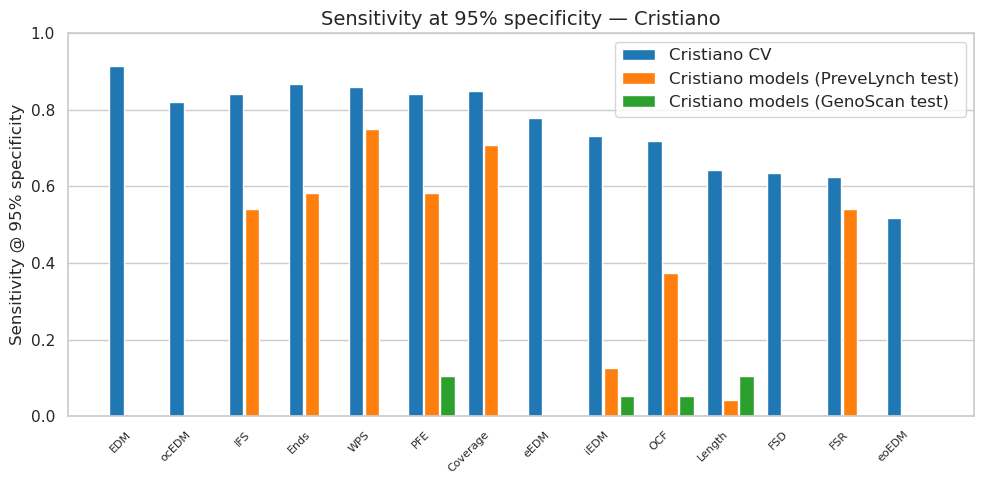

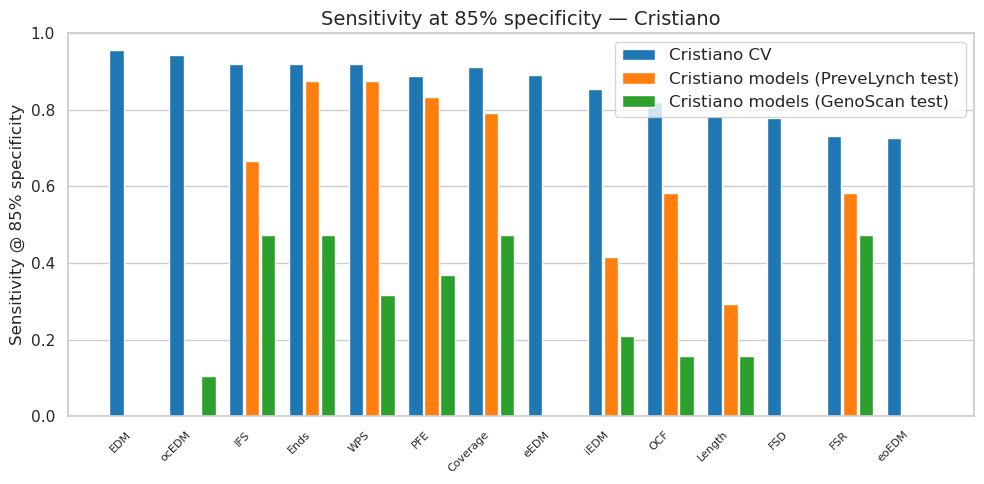

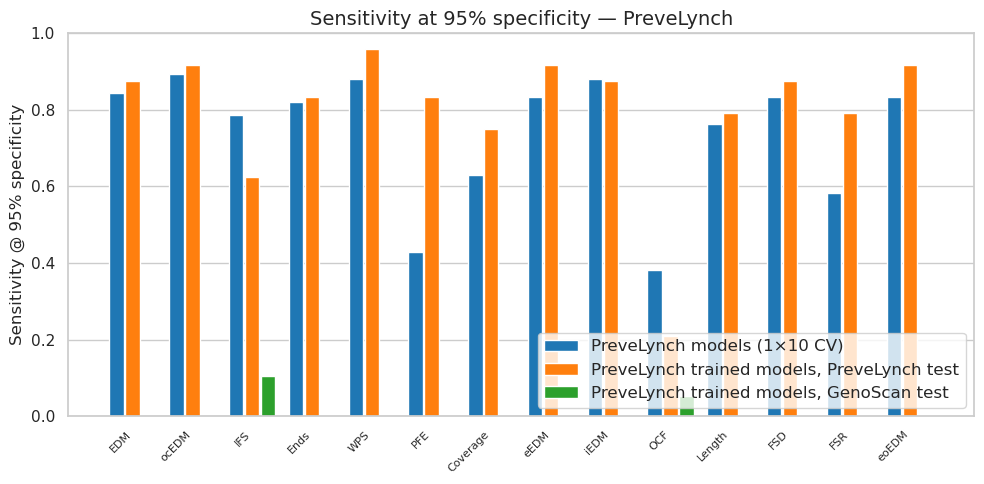

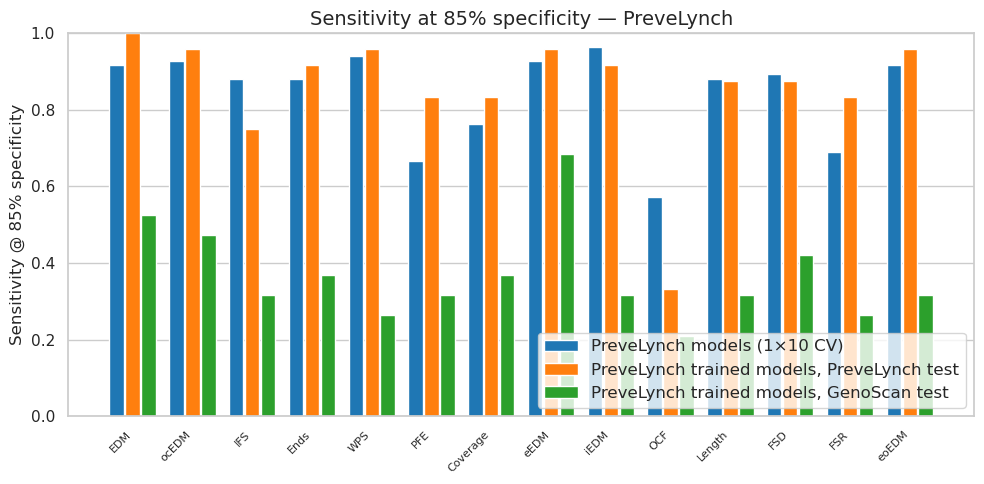

In [148]:
feat_order_e = [d['name'] for d in cv_roc]  # AUC desc order
specs = [95, 85]

for group_name, sens_table, roc_dict in [
    ('Cristiano', sens_table_cristiano, roc_dict_cristiano),
    # ('PreveLynch',        sens_table_ly,        roc_dict_ly),
    ('PreveLynch',    sens_table_ly_cv1,    roc_dict_ly_cv1),
]:
    conditions = list(roc_dict.keys())
    cond_colors = dict(zip(conditions, sns.color_palette('tab10', len(conditions))))
    avail_feats = [f for f in feat_order_e if f in sens_table.index]
    x = np.arange(len(avail_feats))
    width = 0.8 / len(conditions)

    for spec in specs:
        cols = [f"{cond}_sens{spec}" for cond in conditions]
        plot_df = sens_table.loc[avail_feats, cols].copy()
        plot_df.columns = conditions

        fig, ax = plt.subplots(figsize=(10, 5))
        for k, cond in enumerate(conditions):
            offset = (k - (len(conditions) - 1) / 2) * width
            ax.bar(x + offset, plot_df[cond], width=width * 0.9,
                   color=cond_colors[cond], label=cond)
        ax.set_xticks(x)
        ax.set_xticklabels(avail_feats, rotation=45, ha='right', fontsize=8)
        ax.set_ylim(0, 1)
        ax.set_ylabel(f'Sensitivity @ {spec}% specificity')
        ax.set_title(f'Sensitivity at {spec}% specificity — {group_name}', fontsize=14)
        ax.axhline(0, color='black', linewidth=0.5)
        if group_name == 'Cristiano':
            ax.legend(fontsize=12, loc='upper right')
        else:
            ax.legend(fontsize=12, loc='lower right')
        ax.xaxis.grid(False)
        plt.tight_layout()
        fname = f'scripts/analysis/figures/E_sensitivity_{group_name.lower()}_spec{spec}.png'
        plt.savefig(fname, bbox_inches='tight')
        plt.show()

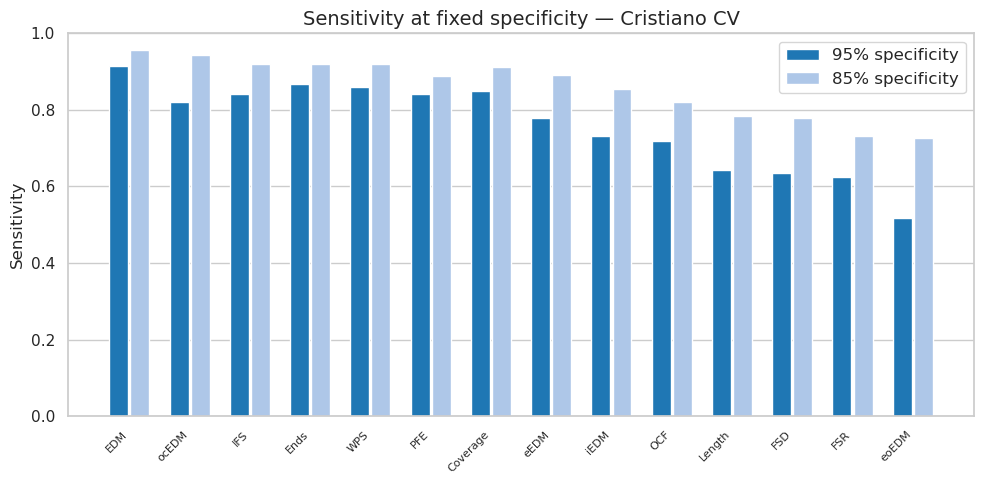

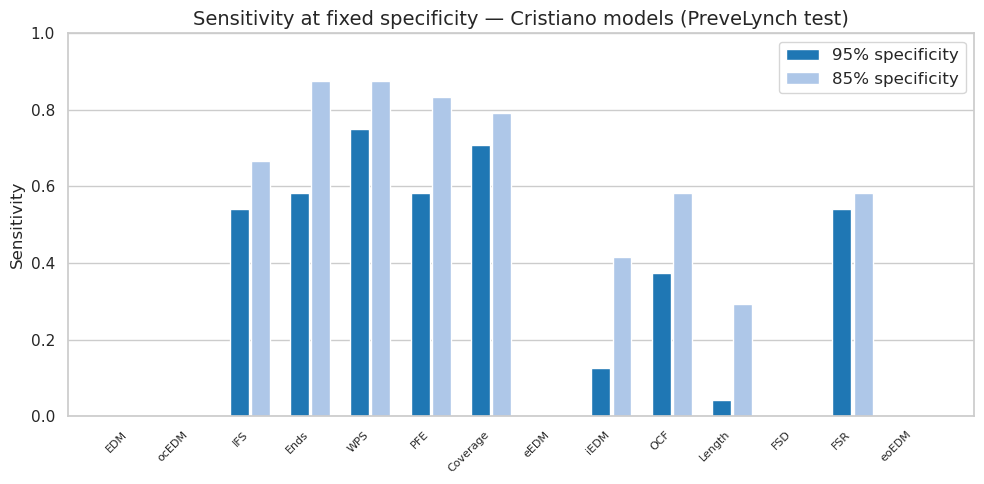

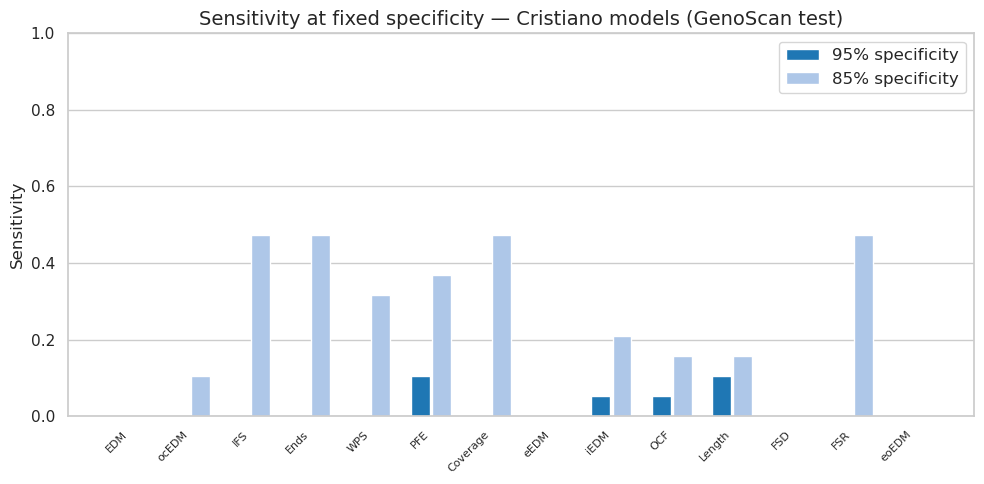

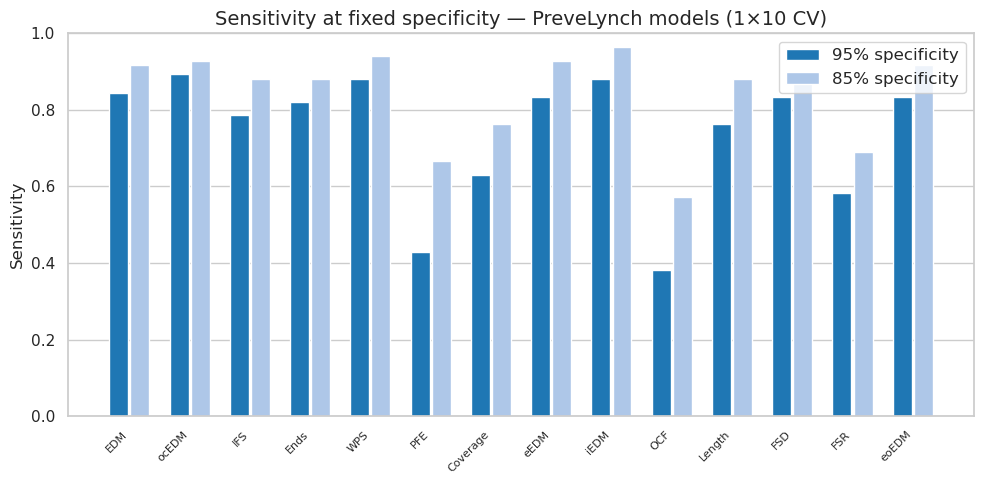

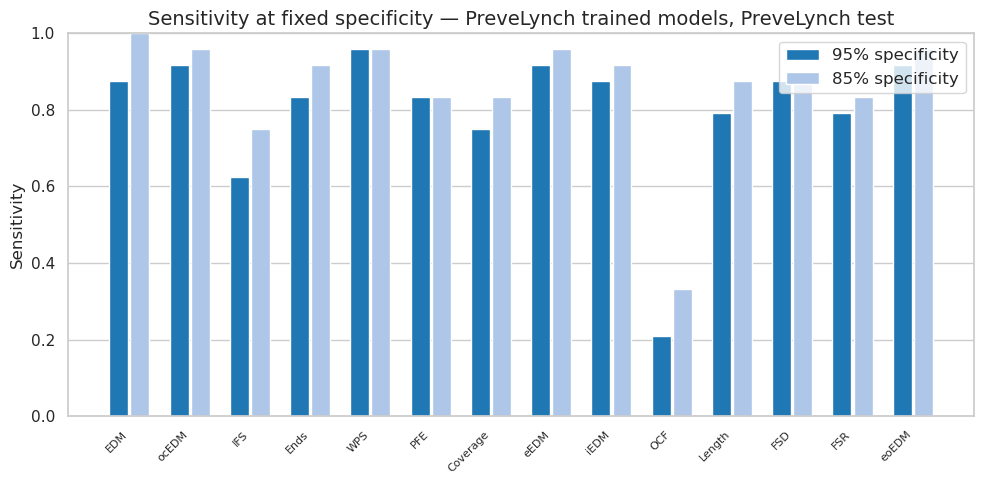

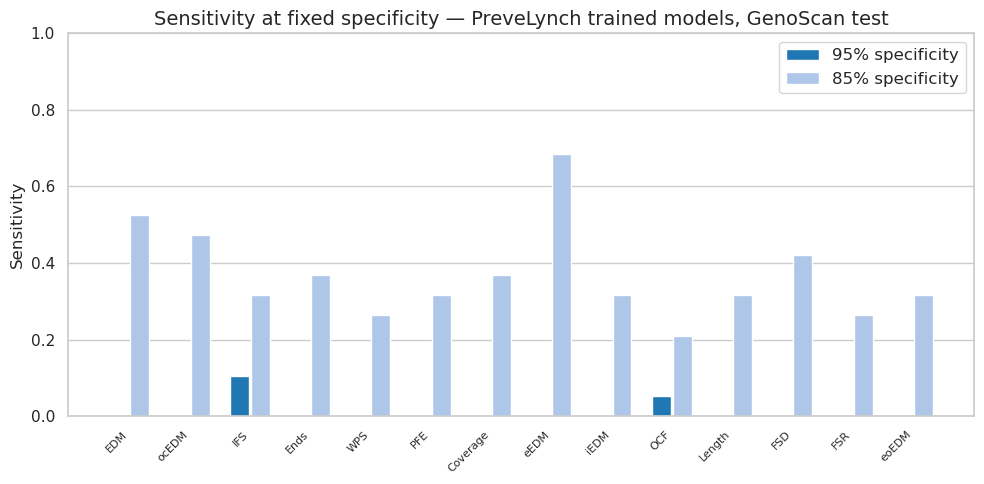

In [149]:
temp_palette = sns.color_palette('tab20')
spec_colors = {95: temp_palette[0], 85: temp_palette[1]}
width = 0.35

for group_name, sens_table, roc_dict in [
    ('Cristiano', sens_table_cristiano, roc_dict_cristiano),
    # ('PreveLynch',        sens_table_ly,        roc_dict_ly),
    ('PreveLynch',    sens_table_ly_cv1,    roc_dict_ly_cv1),
]:
    avail_feats = [f for f in feat_order_e if f in sens_table.index]
    x = np.arange(len(avail_feats))

    for cond in roc_dict.keys():
        fig, ax = plt.subplots(figsize=(10, 5))
        for k, spec in enumerate([95, 85]):
            col = f"{cond}_sens{spec}"
            offset = (k - 0.5) * width
            ax.bar(x + offset, sens_table.loc[avail_feats, col],
                   width=width * 0.9, color=spec_colors[spec], label=f'{spec}% specificity')
        ax.set_xticks(x)
        ax.set_xticklabels(avail_feats, rotation=45, ha='right', fontsize=8)
        ax.set_ylim(0, 1)
        ax.set_ylabel('Sensitivity')
        ax.set_title(f'Sensitivity at fixed specificity — {cond}', fontsize=14)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.legend(fontsize=12, loc='upper right')
        ax.xaxis.grid(False)
        plt.tight_layout()
        plt.savefig(f'scripts/analysis/figures/E_sensitivity_{group_name.lower()}_{cond.replace(" ", "_")}.png', bbox_inches='tight')
        plt.show()


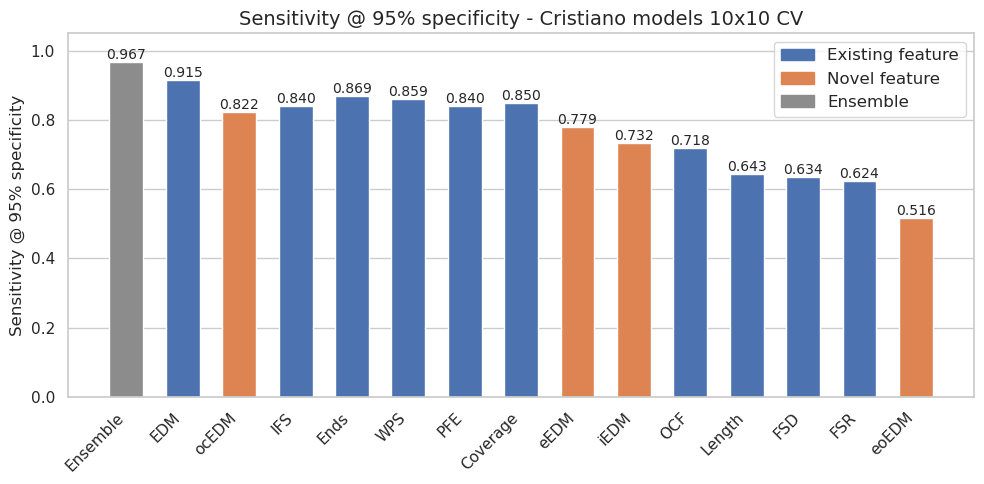

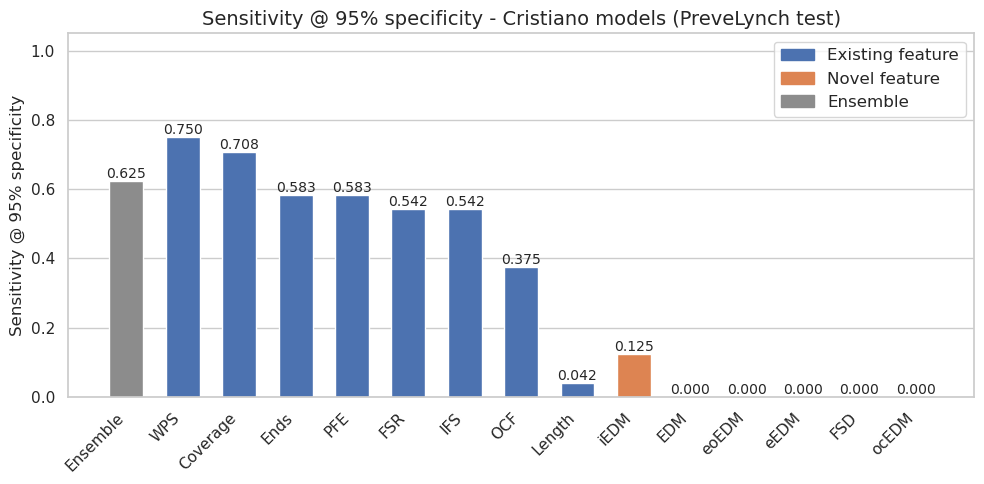

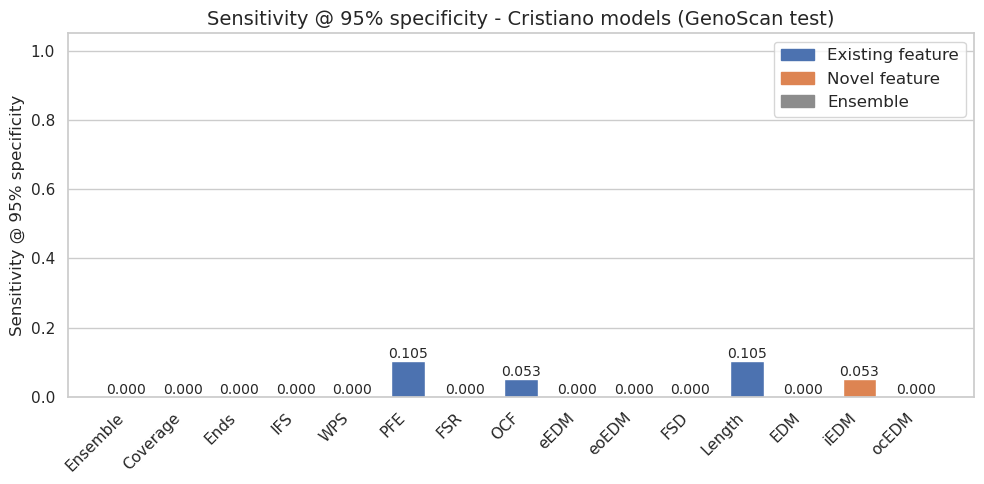

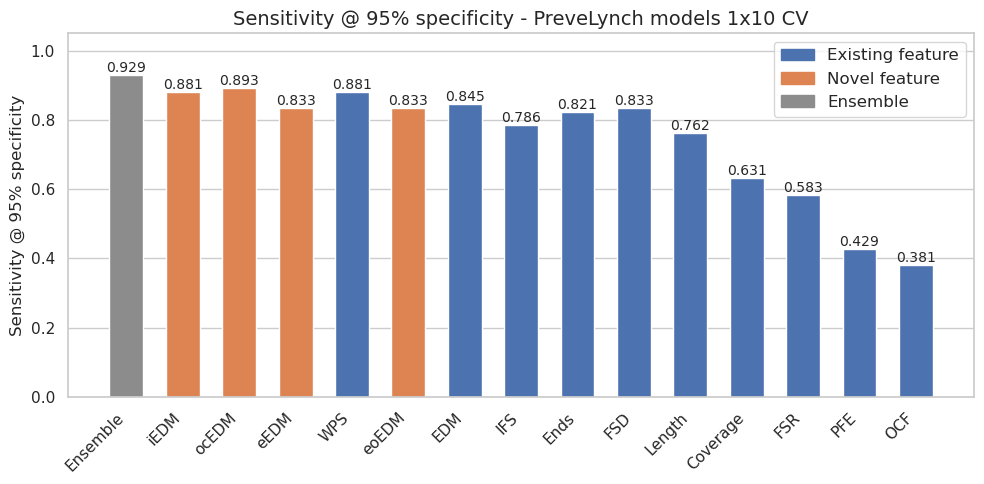

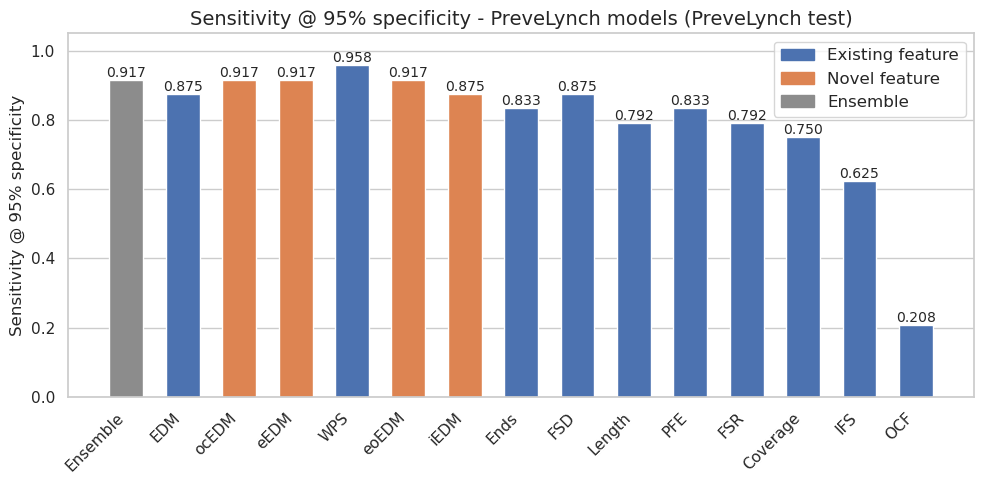

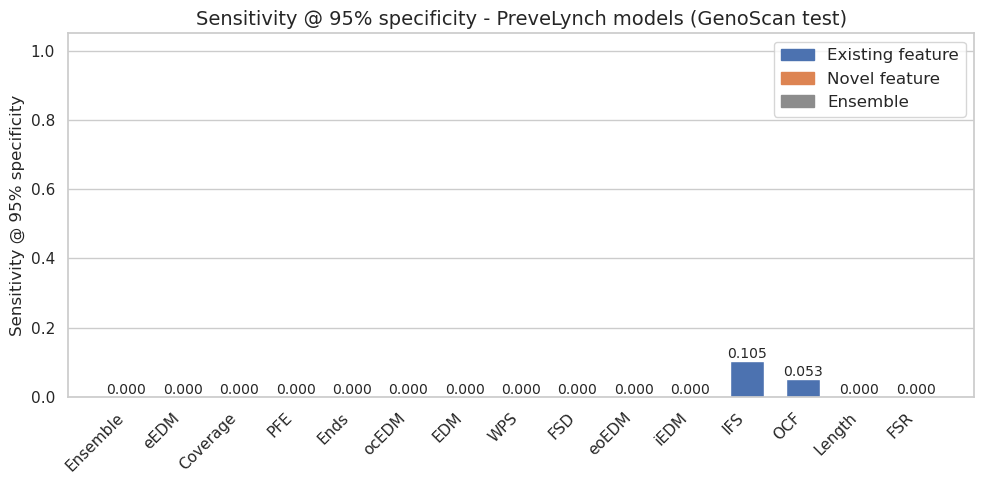

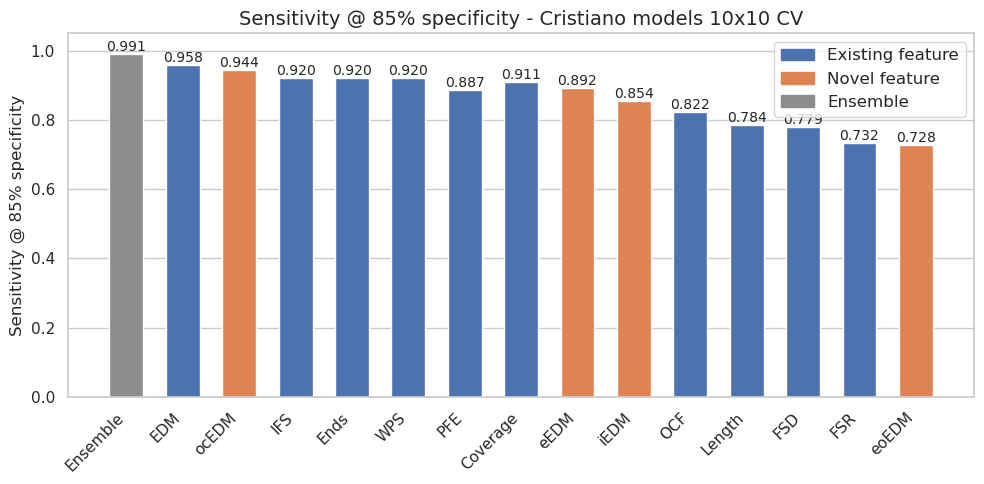

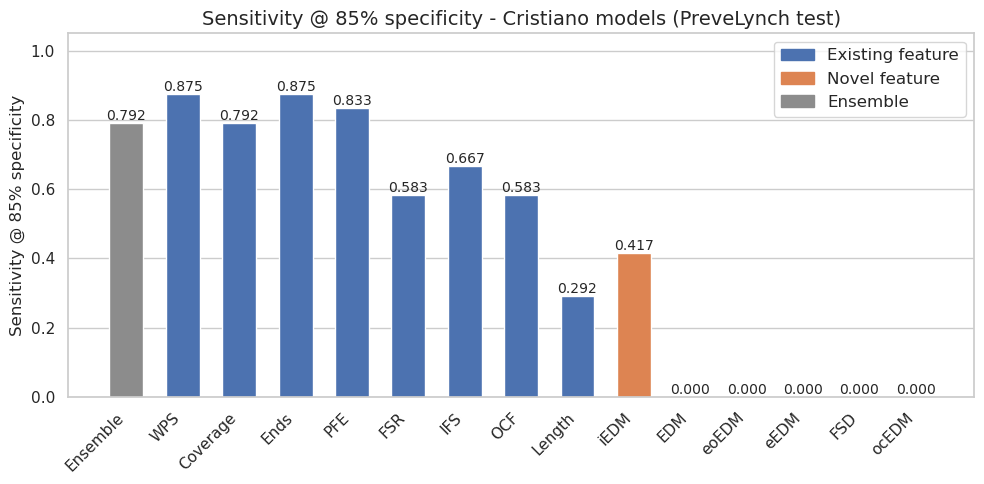

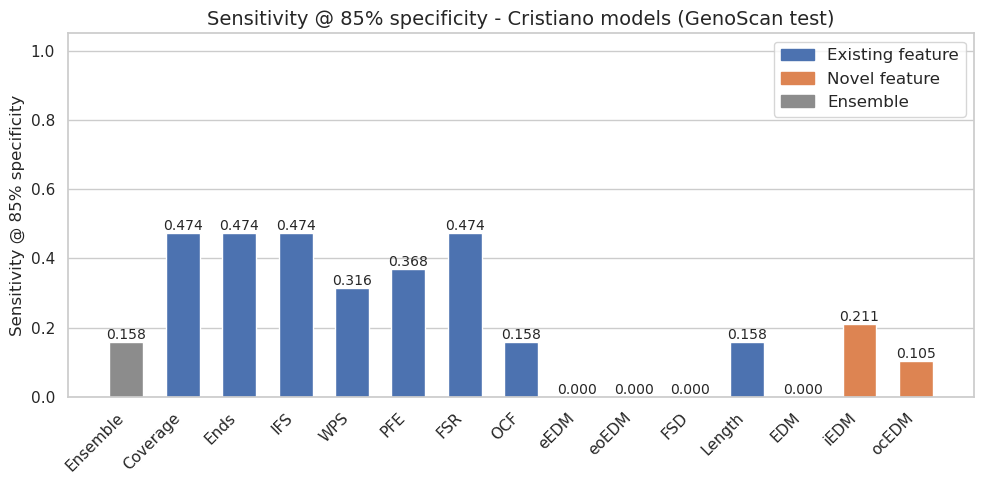

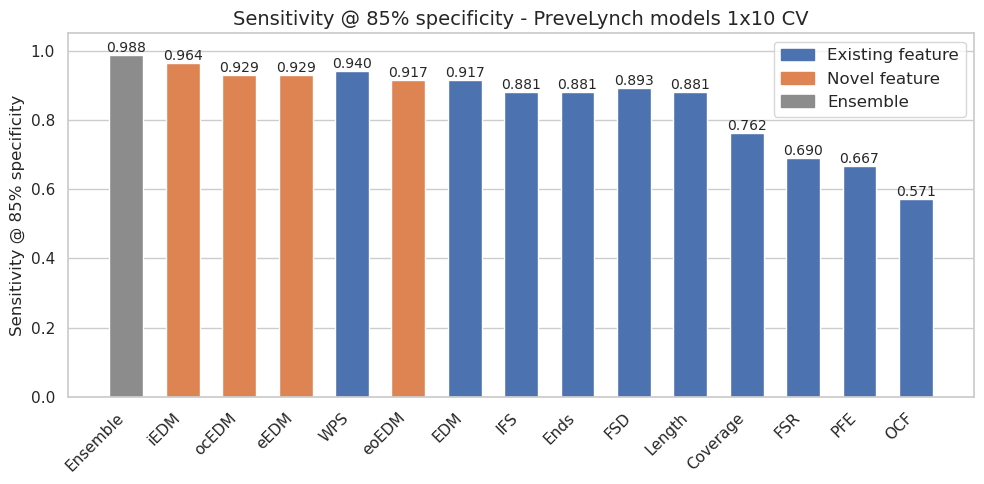

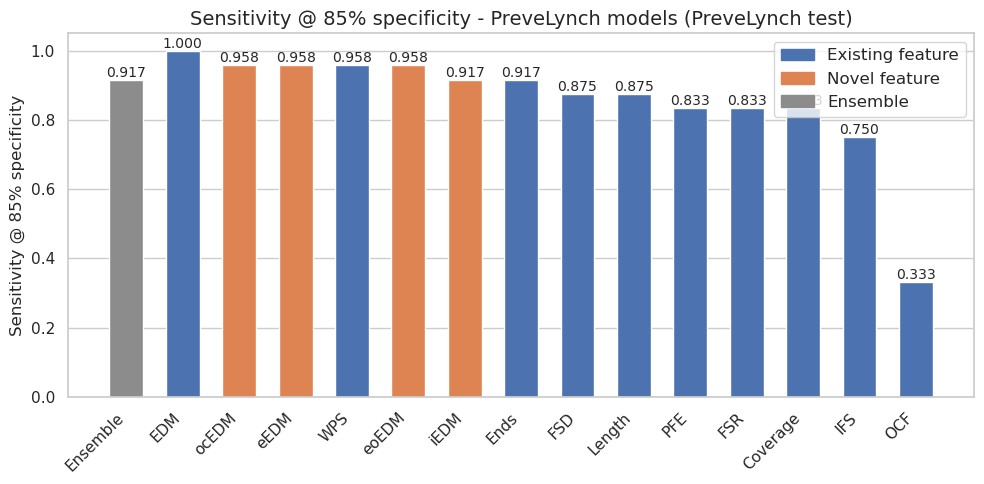

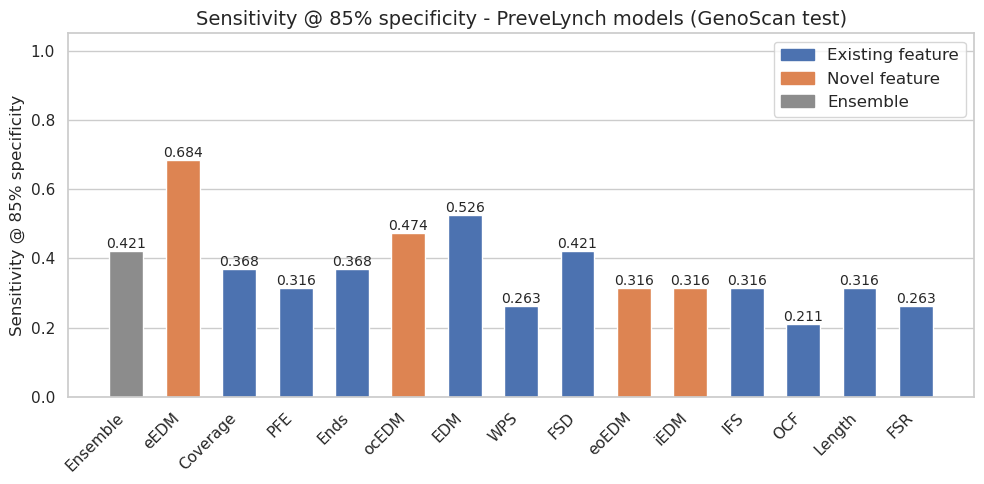

In [150]:
# E — Sensitivity at fixed specificity: per-feature + ensemble per condition
ENSEMBLE_COLOR = old_palette[7]
SENS_SPECS = (0.95, 0.85)

ly_cv1_gs_test_roc = load_roc_data('data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_cv1_mapq30_v2/test/genoscan/')
ly_cv1_ly_test_roc = load_roc_data('data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_cv1_mapq30_v2/test/prevelynch_test/')
ly_cv1_ens_gs_df = pd.read_csv('data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_cv1_mapq30_v2/ensemble_nostd/test/genoscan_preds.csv')
ly_cv1_ens_ly_df = pd.read_csv('data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_cv1_mapq30_v2/ensemble_nostd/test/prevelynch_test_preds.csv')

ENS_CONDITIONS = [
    ('Cristiano models 10x10 CV',              cv_roc,              ens_df,              'cristiano_cv'),
    ('Cristiano models (PreveLynch test)',    cr_ly_roc,           cr_ens_ly_df,        'crist_ly'),
    ('Cristiano models (GenoScan test)',      cr_gs_roc,           cr_ens_gs_df,        'crist_gs'),
    ('PreveLynch models 1x10 CV',             ly_cv1_roc,          ly_cv1_ens_df,       'ly_cv1'),
    ('PreveLynch models (PreveLynch test)',  ly_cv1_ly_test_roc,  ly_cv1_ens_ly_df,    'ly_cv1_ly'),
    ('PreveLynch models (GenoScan test)',    ly_cv1_gs_test_roc,  ly_cv1_ens_gs_df,    'ly_cv1_gs'),
]

for spec in SENS_SPECS:
    spec_pct = int(spec * 100)
    for cond_name, feat_roc, ens_df_c, slug in ENS_CONDITIONS:
        feat_names = [d['name'] for d in feat_roc]
        feat_sens  = [sens_at_spec(d['fpr'], d['tpr'], spec) for d in feat_roc]
        ens_fpr_c, ens_tpr_c, _ = roc_curve(ens_df_c['label'], ens_df_c['probability'])
        ens_sens = sens_at_spec(ens_fpr_c, ens_tpr_c, spec)

        bar_names  = ['Ensemble'] + feat_names
        bar_vals   = [ens_sens] + feat_sens
        bar_colors = [ENSEMBLE_COLOR] + [is_new_color(n) for n in feat_names]

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(range(len(bar_names)), bar_vals, color=bar_colors, width=0.6)
        ax.set_xticks(range(len(bar_names)))
        ax.set_xticklabels(bar_names, rotation=45, ha='right')
        ax.set_ylim(0, 1.05)
        ax.set_ylabel(f'Sensitivity @ {spec_pct}% specificity')
        ax.set_title(f'Sensitivity @ {spec_pct}% specificity - {cond_name}', fontsize=14)
        ax.legend(handles=[Patch(color=old_palette[0], label='Existing feature'),
                           Patch(color=old_palette[1], label='Novel feature'),
                           Patch(color=ENSEMBLE_COLOR, label='Ensemble')],
                  loc='upper right', fontsize=12)
        for p in ax.patches:
            ax.annotate(f'{p.get_height():.3f}',
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=10)
        ax.xaxis.grid(False)
        plt.tight_layout()
        plt.savefig(f'scripts/analysis/figures/E_sens_spec{spec_pct}_{slug}.png',
                    bbox_inches='tight')
        plt.show()